# FPGrowth and Collaborative Filtering

## Introduction

### 1. Overall idea of the hybrid model

The hybrid pipeline is:

1. **Stage 1 (Pattern mining)**  
   - From historical transaction / basket data (e.g. user–item interactions), mine **frequent itemsets** (and optionally association rules) using **FPGrowth**.
   - Use these patterns to:
     - pre‑filter candidate items,
     - enrich the user–item matrix, or
     - generate "warm‑up" recommendations before CF.

2. **Stage 2 (Personalization)**  
   - Feed the refined input (e.g. filtered items, or boosted weights from FP‑patterns) into a **Collaborative Filtering** model (e.g. user‑based, item‑based, or matrix‑factorization‑based).
   - The CF model then outputs **personalized recommendations** for each user.

This two‑stage design helps overcome **sparsity and cold‑start** issues by leveraging association patterns first, then fine‑tuning with user‑behavior similarity. [pdfs.semanticscholar](https://pdfs.semanticscholar.org/6259/f01d784a0b3c7a4a614eb8e75e3ab086bced.pdf)


### 2. Stage 1: FPGrowth
#### Input notation
Let:
- $D = \{T_1, T_2, \dots, T_n\}$ be a **transaction database**,  
  where $T_i \subseteq I$ is a transaction (basket) and $I = \{i_1, i_2, \dots, i_m\}$ is the set of all items. [philippe-fournier-viger](https://www.philippe-fournier-viger.com/spmf/FPGrowth.php)
- $\text{minsup} \in (0,1]$ the **minimum support threshold**.
- $\text{supp}(X)$ the **support** of itemset $X$:  
  $$
  \text{supp}(X) = \frac{\#\{T \in D \mid X \subseteq T\}}{|D|}
  $$
  i.e., the fraction of transactions containing $X$. [philippe-fournier-viger](https://www.philippe-fournier-viger.com/spmf/FPGrowth.php)
  
  A **frequent itemset** $X$ is one where:
$$
\text{supp}(X) \geq \text{minsup}
$$

#### FP‑Tree and mining (high‑level math)
The FP‑Growth algorithm proceeds in two main steps:
1. **Build the FP‑Tree**  
   - Scan the database once to compute $f(j)$, the frequency of item $j$.
   - Remove items with $f(j) < \text{minsup}$ (infrequent).
   - Order the remaining items by frequency (descending).
   - For each transaction $T_i$:
     - keep only the frequent items,
     - sort them by frequency order,
     - insert this ordered itemset into the **FP‑Tree** (a compressed prefix tree with counts). [geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/frequent-pattern-growth-algorithm/)

2. **Mine frequent itemsets via conditional FP‑Trees**  
   - For each frequent item $z$, build a **conditional pattern base**:
     $$
     \text{CPB}(z) = \bigcup_{\text{all paths ending with } z} \text{prefix paths}
     $$
   - From $\text{CPB}(z)$, construct a **conditional FP‑Tree** for item $z$, and recursively mine patterns of the form:
   $$
     X \cup \{z\}
   $$
     
     where $X$ is a frequent itemset in the conditional tree. [geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/frequent-pattern-growth-algorithm/)

#### Optional: association rules
After getting frequent itemsets, you can derive **association rules** $X \rightarrow Y$ where $X \cap Y = \emptyset$.
- **Support** of rule $X \rightarrow Y$:
  $$
  \text{supp}(X \rightarrow Y) = \text{supp}(X \cup Y)
  $$

- **Confidence** of rule $X \rightarrow Y$:
  $$
  \text{conf}(X \rightarrow Y) = \frac{\text{supp}(X \cup Y)}{\text{supp}(X)}
  $$

In your hybrid model, you might keep only rules with $\text{supp} \geq \text{minsup}$ and $\text{conf} \geq \text{minconf}$. [scaler](https://www.scaler.com/topics/data-mining-tutorial/fp-growth-in-data-mining/)

#### How you use FP‑results in Stage 1 output
From Stage 1 you can output:
- A set of frequent itemsets $\mathcal{F} = \{X \mid \text{supp}(X) \geq \text{minsup}\}$.
- Or a set of strong association rules $\mathcal{R} = \{X \rightarrow Y \mid \text{supp} \geq \text{minsup}, \text{conf} \geq \text{minconf}\}$.

You can then:
- **Boost item co‑occurrence weights** in the user–item matrix (e.g., add small weights proportional to support or confidence).
- Or **pre‑filter candidates**: for user $u$, only consider items $i$ that appear in frequent patterns involving items $u$ has interacted with. [jiita](http://jiita.org/jiita/vol7/JIITA_Vol7_No1_p.654-665.pdf)

***

### 3. Stage 2: Collaborative Filtering (math & equations)
Let:
- $U = \{u_1, u_2, \dots, u_n\}$ be the set of **users**.
- $I = \{i_1, i_2, \dots, i_m\}$ be the set of **items**.
- $R \in \mathbb{R}^{n \times m}$ be the **rating / interaction matrix**, where $r_{u i}$ is the rating (or implicit feedback, e.g. 1 = purchased, 0 = not) that user $u$ gave to item $i$. [ibm](https://www.ibm.com/think/topics/collaborative-filtering)

#### Option A: User‑based or item‑based CF (neighborhood methods)
##### Similarity (cosine as example)
For **user‑based CF**, similarity between users $u$ and $v$ (over items they both rated):
$$
\text{sim}(u, v) = \frac{
\sum_{i \in I_{uv}} (r_{u i} - \bar{r}_u)(r_{v i} - \bar{r}_v)
}{
\sqrt{\sum_{i \in I_{uv}} (r_{u i} - \bar{r}_u)^2}
\sqrt{\sum_{i \in I_{uv}} (r_{v i} - \bar{r}_v)^2}
}
$$
where:
- $I_{uv}$ = items rated by both $u$ and $v$,
- $\bar{r}_u$ = average rating of user $u$. [cs.princeton](https://www.cs.princeton.edu/courses/archive/spring17/cos435/Notes/search_refine_rec_topostPart2.pdf)

In **item‑based CF**, same formula applies to items $i$ and $j$, with similarity over users who rated both.

##### Prediction (user‑based example)
To predict rating $\hat{r}_{u i}$ for user $u$ and item $i$:
$$
\hat{r}_{u i} = \bar{r}_u +
\frac{
\sum_{v \in N_u(i)} \text{sim}(u, v) (r_{v i} - \bar{r}_v)
}{
\sum_{v \in N_u(i)} |\text{sim}(u, v)|
}
$$
where $N_u(i)$ is the set of “neighbor” users of $u$ who have rated item $i$. [ibm](https://www.ibm.com/think/topics/collaborative-filtering)

You can use FP‑Growth results to:
- **restrict the candidate set** to items related via strong association rules to $u$’s history,
- or to **weight the similarity** by pattern strength (e.g., higher similarity if users share frequent itemsets).

#### Option B: Matrix factorization CF (e.g., SVD / ALS)
Represent users and items in latent space:
- Each user $u$ → vector $\mathbf{p}_u \in \mathbb{R}^k$.
- Each item $i$ → vector $\mathbf{q}_i \in \mathbb{R}^k$.

Then predicted rating:
$$
\hat{r}_{u i} = \mathbf{p}_u^\top \mathbf{q}_i
$$

Optimization (minimize reconstruction loss + regularization):
$$
\min_{\mathbf{P}, \mathbf{Q}} \sum_{(u,i) \in \mathcal{O}} (r_{u i} - \mathbf{p}_u^\top \mathbf{q}_i)^2
+ \lambda \left(
\|\mathbf{P}\|_{F}^2 + \|\mathbf{Q}\|_{F}^2
\right)
$$
where:
- $\mathcal{O}$ = observed ratings,
- $\|\cdot\|_F$ is Frobenius norm,
- $\lambda$ controls regularization. [cs.princeton](https://www.cs.princeton.edu/courses/archive/spring17/cos435/Notes/search_refine_rec_topostPart2.pdf)

You can **incorporate FP‑Growth patterns** into MF‑like CF by:
- Using **support/confidence values** to **increase weights** of related item pairs in the loss,
- Or **initializing** $\mathbf{q}_i$ vectors such that items appearing together in frequent patterns are closer in the embedding space.

***

### 4. How the two stages connect (hybrid logic)
A concrete pipeline:
1. **Stage 1 (FPGrowth)**  
   - Input: transaction data $D$ (e.g., orders, baskets).
   - Output: frequent itemsets $\mathcal{F}$ or association rules $\mathcal{R}$.

2. **Refine/weight the user–item matrix using FP‑results**  
   - For each user $u$, identify all items $I_u$ they have interacted with.
   - For each association rule $X \rightarrow Y$ where $X \subseteq I_u$ and $Y \not\subseteq I_u$:
     - Add a **weight** $w_{u y} = \text{conf}(X \rightarrow Y)$ or a function of $\text{supp}(X \cup Y)$ to item $y$ for user $u$.
   - This effectively creates a **pre‑filtered and boosted interaction matrix** $R'$.

3. **Stage 2 (CF)**  
   - Feed $R'$ (or the raw $R$ with FP‑enhanced weights) into:
     - a **user‑/item‑based CF** model, or
     - a **matrix‑factorization** model.
   - CF outputs predicted scores $\hat{r}_{u i}$ for un‑interacted items $i$.

4. **Final recommendation**  
   - For user $u$, rank items $i$ by $\hat{r}_{u i}$,
   - Output top‑$K$ items as recommendations.

This **two‑stage hybrid** leverages **global patterns from FPGrowth** first, then **personalizes** with CF, improving robustness to sparsity and cold start. [ijcrt](https://www.ijcrt.org/papers/IJCRT2603275.pdf)

***

# Module Loading

In [1]:
import gdown
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pylab import rcParams
import pandas as pd
import numpy as np
from google.colab import drive
from warnings import filterwarnings

drive.mount('/content/drive', force_remount = False)
dbpath = '/content/drive/MyDrive/Colab Notebooks/DB_ga4_ecommerce.duckdb'

Mounted at /content/drive


In [2]:
# Modern Professional Color Palette
modern_colors = [
    "#1f77b4",   # Vibrant Blue (Primary)
    "#ff7f0e",   # Bright Orange (Accent/Comparison)
    "#2ca02c",   # Fresh Green (Success/Positive)
    "#d62728",   # Soft Red (Alert/Warning)
    "#9467bd",   # Elegant Purple
    "#8c564b",   # Warm Brown
    "#e377c2",   # Pink
    "#7f7f7f",   # Neutral Gray
    "#bcbd22",   # Olive/Yellow-Green
    "#17becf"    # Cyan/Teal
]

# 2. Main Style Dictionary
modern_light_style = {
    # Background - Clean and bright
    "figure.facecolor": "#ffffff",
    "axes.facecolor": "#f8f9fa",
    "savefig.facecolor": "#ffffff",

    # Grid - Very subtle and non-distracting
    "axes.grid": True,
    "grid.color": "#e6e8eb",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
    "axes.grid.which": "both",

    # Typography
    "text.color": "#1f2937",
    "axes.labelcolor": "#1f2937",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.titlepad": 18,
    "font.size": 12,
    "font.family": "sans-serif", # You can change to 'Arial', 'Helvetica', etc.

    # Spines - Clean and minimal
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "#4b5563",
    "axes.linewidth": 1.2,

    # Lines and markers
    "axes.prop_cycle": plt.cycler(color=modern_colors),
    "lines.linewidth": 2.5,
    "lines.markersize": 7,
    "lines.markeredgewidth": 0.8,

    # Patches (bars, areas, etc.)
    "patch.edgecolor": "#ffffff",
    "patch.linewidth": 0.8,

    # Legend
    "legend.frameon": False,
    "legend.loc": "best",
    "legend.fontsize": 11,
}

plt.style.use('default')
sns.set_theme(style="whitegrid", rc=modern_light_style)
plt.rcParams.update(modern_light_style)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=modern_colors)

In [3]:
def CSV_gdrive(file_id:str,
               output_filename: str= None,
               show_head : bool= True,
              ) -> pd.DataFrame:
    if output_filename is None:
        output_filename = 'downloaded_file.csv'
    gdrive_url = f'https://drive.google.com/uc?id={file_id}'
    df = pd.DataFrame()
    try:
        gdown.download(gdrive_url, output_filename, quiet=False)
        df = pd.read_csv(output_filename)
        if show_head:
            display(df.head(3))
    except Exception as e:
        print(f"An error occurred: {e}")
        print("Please ensure the file ID is correct and the file is publicly accessible.")
    finally:
        return df


# Data Mounting

In [4]:
Thefile = '/content/drive/My Drive/Colab Notebooks/ga4_obfuscated_sample_ecommerce.parquet'
Already_Parquet = True  if os.path.exists(Thefile) else False

if not Already_Parquet:
    file_id = '14dtPTtcGX_Hg-Pteg-_ovqbZX1eID24A'
    output_filename = 'ga4_obfuscated_sample_ecommerce.csv'
    Data = CSV_gdrive(file_id, output_filename, show_head=True)

In [5]:
if not Already_Parquet:
    dirLoc = '/content/drive/My Drive/Colab Notebooks/'
    output = dirLoc + 'ga4_obfuscated_sample_ecommerce.parquet'
    Data.to_parquet(output, compression='brotli')
    print(f"DataFrame saved to {output} with Brotli compression.")

In [6]:
if Already_Parquet:
    MasterData = pd.read_parquet(Thefile)

# Data Engineering

## 0. Imports & Global Configuration

In [ ]:
!pip install -q tqdm_joblib mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
from __future__ import annotations

import os
import logging
import warnings
from typing import Dict, List, Tuple, Optional, Union, Any

import numpy as np
import pandas as pd
import duckdb
import pyarrow as pa
import pyarrow.parquet as pq

from joblib import Parallel, delayed, dump, load
from tqdm.auto import tqdm
from tqdm_joblib import tqdm_joblib

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

import mlflow
import cloudpickle

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s"
)

logger = logging.getLogger(__name__)

## 1. DuckDB Connection Manager

In [ ]:
def create_duckdb_connection(
    db_path: Optional[str] = None
) -> duckdb.DuckDBPyConnection:

    logger.debug("Creating DuckDB connection")

    try:
        if db_path:
            conn = duckdb.connect(db_path)
        else:
            conn = duckdb.connect()

        logger.debug("DuckDB connection created")
        return conn

    except Exception as e:
        logger.exception("DuckDB connection failed")
        raise ValueError("DuckDB connection failed") from e

## 2. CSV --> Parquet Converter

In [ ]:
def csv_to_parquet(
    csv_path: str,
    parquet_path: str
) -> None:

    logger.debug("Converting CSV to Parquet")

    if not os.path.exists(csv_path):
        raise ValueError("CSV file not found")

    try:
        duckdb.query(
            f"""
            COPY (
                SELECT * FROM read_csv_auto('{csv_path}')
            )
            TO '{parquet_path}' (FORMAT PARQUET)
            """
        )

    except Exception as e:
        logger.exception("CSV conversion failed")
        raise ValueError("CSV to parquet failed") from e

## 3. Load Parquet into DuckDB

In [ ]:
def load_parquet_to_duckdb(
    conn: duckdb.DuckDBPyConnection,
    parquet_path: str,
    table_name: str
) -> None:

    logger.debug("Loading parquet to DuckDB")

    if not os.path.exists(parquet_path):
        raise ValueError("Parquet file not found")

    try:
        conn.execute(
            f"CREATE OR REPLACE TABLE {table_name} AS SELECT * FROM read_parquet('{parquet_path}')"
        )

    except Exception as e:
        logger.exception("Load parquet failed")
        raise ValueError("Load parquet failed") from e

## 4. DuckDB Query Executor

In [ ]:
def run_duckdb_query(
    conn: duckdb.DuckDBPyConnection,
    query: str,
    return_df: bool = True
) -> Optional[pd.DataFrame]:

    logger.debug("Executing DuckDB query")

    try:
        result = conn.execute(query)

        if return_df:
            return result.df()

        return None

    except Exception as e:
        logger.exception("DuckDB query failed")
        raise ValueError("DuckDB query failed") from e

## 5. DuckDB Missing Summary

In [ ]:
def duckdb_missing_summary(
    conn: duckdb.DuckDBPyConnection,
    table_name: str
) -> pd.DataFrame:

    logger.debug("Computing missing summary")

    try:
        cols = conn.execute(
            f"PRAGMA table_info({table_name})"
        ).df()["name"].tolist()

        queries = [
            f"SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) as {c}"
            for c in cols
        ]

        query = f"SELECT {','.join(queries)} FROM {table_name}"

        return conn.execute(query).df()

    except Exception as e:
        logger.exception("Missing summary failed")
        raise ValueError("Missing summary failed") from e

## 6. DuckDB User Level Features

In [ ]:
def create_user_level_features_duckdb(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    user_col: str = "user_id"
) -> pd.DataFrame:
    query = f"""
    SELECT
        {user_col},
        COUNT(*) as total_interactions,
        COUNT(DISTINCT product_id) as unique_products,
        SUM(view_count) as total_views,
        SUM(add_to_cart_count) as total_add_to_carts,
        SUM(purchase_count) as total_purchases,
        SUM(total_quantity) as total_units
    FROM {table_name}
    GROUP BY {user_col}
    """
    return conn.execute(query).df()


## 7. Safe Sampling for Visualization

In [ ]:
def duckdb_sample(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    fraction: float = 0.1
) -> pd.DataFrame:

    logger.debug("Sampling DuckDB table")

    query = f"SELECT * FROM {table_name} USING SAMPLE {fraction}"

    return conn.execute(query).df()

## 8. Label Encoding (Production Safe)

In [ ]:
def fit_label_encoders(
    df: pd.DataFrame,
    columns: List[str],
    save_path: str
) -> Dict[str, LabelEncoder]:

    logger.debug("Fitting label encoders")

    encoders: Dict[str, LabelEncoder] = {}

    try:
        for col in columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le

        dump(encoders, save_path)

        return encoders

    except Exception as e:
        logger.exception("Label encoder failed")
        raise ValueError("Label encoder failed") from e

## 9. Reverse Label Encoding

In [ ]:
def inverse_label_encoding(
    df: pd.DataFrame,
    encoder_path: str
) -> pd.DataFrame:

    logger.debug("Inverse label encoding")

    encoders = load(encoder_path)

    for col, encoder in encoders.items():
        df[col] = encoder.inverse_transform(df[col])

    return df

## 10. Visualization (Safe Sampling Only)

In [ ]:
def plot_distribution(
    df: pd.DataFrame,
    column: str
) -> None:

    logger.debug("Plotting distribution")

    plt.figure(figsize=(10,6))
    sns.histplot(df[column], kde=True)
    plt.show()

## 11. MLflow Tracking

In [ ]:
def start_mlflow_experiment(
    experiment_name: str
) -> None:

    logger.debug("Starting MLflow")

    mlflow.set_experiment(experiment_name)
    mlflow.start_run()

## 12. Genetic Feature Selection

In [ ]:
def genetic_feature_selection(
    X: pd.DataFrame,
    y: pd.Series = None,
    generations: int = 10,
    population_size: int = 20,
    mutation_rate: float = 0.1,
    n_jobs: int = -1
) -> List[str]:
    """
    Optimized Genetic Algorithm for Feature Selection.
    Much better than the previous random version.
    """
    logger.info("\nStarting Genetic Feature Selection...\n")
    logger.info(f"Generations: {generations} | Population: {population_size}\n")

    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score
    import numpy as np

    features = list(X.columns)
    n_features = len(features)

    if y is None:
        logger.warning("No target 'y' provided. Using proxy target (total_purchases or total_interactions)")
        # Create proxy target for unsupervised case
        if 'purchase' in X.columns:
            y = (X['purchase'] > 0).astype(int)
        elif 'total_purchases' in X.columns:
            y = (X['total_purchases'] > 0).astype(int)
        else:
            y = (X.iloc[:, -1] > X.iloc[:, -1].median()).astype(int)  # fallback

    # Initialize population
    population = list()
    for _ in range(population_size):
        # Random subset between 30% to 70% of features
        subset_size = np.random.randint(int(0.3*n_features), int(0.7*n_features) + 1)
        subset = np.random.choice(features, size=subset_size, replace=False)
        population.append(set(subset))

    best_features = list()
    best_score = -np.inf

    for gen in range(generations):
        logger.info(f"Generation {gen+1}/{generations}")

        scores = list()
        new_population = list()

        for subset_set in tqdm(population, desc=f"Gen {gen+1}", colour="green"):
            subset = list(subset_set)
            if len(subset) == 0:
                scores.append(0)
                continue

            X_subset = X[subset]

            # Use cross-validation for more robust score
            model = RandomForestClassifier(n_estimators=100, n_jobs=n_jobs, random_state=42)
            score = cross_val_score(model, X_subset, y, cv=3, n_jobs=n_jobs, scoring='f1').mean()
            scores.append(score)

            if score > best_score:
                best_score = score
                best_features = subset
                logger.info(f"New best score: {best_score:.4f} with {len(subset)} features")

        # Elitism: keep top 2
        elite_idx = np.argsort(scores)[-2:]
        new_population = [population[i] for i in elite_idx]

        # Crossover + Mutation
        while len(new_population) < population_size:
            parent1, parent2 = np.random.choice(population, 2, replace=False)
            child = parent1.union(parent2)

            # Mutation
            if np.random.rand() < mutation_rate:
                if np.random.rand() < 0.5 and len(child) > 3:
                    child.pop()  # remove one
                else:
                    new_feat = np.random.choice(features)
                    child.add(new_feat)

            new_population.append(child)

        population = new_population[:population_size]

    logger.info(f"\nGenetic Feature Selection Completed!")
    logger.info(f"Best score: {best_score:.4f}")
    logger.info(f"Selected {len(best_features)} features\n")

    return best_features

## 13. Save Pipeline

In [ ]:
def save_pipeline(
    pipeline: Any,
    path: str
) -> None:

    logger.debug("Saving pipeline")

    with open(path, "wb") as f:
        cloudpickle.dump(pipeline, f)

## 14. Load Pipeline

In [ ]:
def load_pipeline(
    path: str
) -> Any:

    logger.debug("Loading pipeline")

    with open(path, "rb") as f:
        return cloudpickle.load(f)

## 15. Sessionization Features

In [ ]:
def create_session_features(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    user_col: str = "user_id",
    session_col: str = "num_sessions"
) -> pd.DataFrame:
    query = f"""
    SELECT
        {user_col},
        MAX({session_col}) as total_sessions,
        AVG(total_interactions) as avg_events_per_session   -- approximate
    FROM (
        SELECT {user_col}, {session_col},
               COUNT(*) as total_interactions
        FROM {table_name}
        GROUP BY {user_col}, {session_col}
    ) sub
    GROUP BY {user_col}
    """
    return conn.execute(query).df()

## 16. Time Based Features

In [ ]:
def create_time_features(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    timestamp_col: str = "last_interaction_raw_unix_micros"
) -> None:
    """Fixed version for your production data (DuckDB compatible)"""
    logger.info(f"\nCreating time-based features from {timestamp_col}...\n")

    query = f"""
    CREATE OR REPLACE TABLE {table_name} AS
    SELECT *,
        -- Convert microsecond unix timestamp to proper timestamp
        epoch_ms({timestamp_col}) as event_timestamp,

        -- Extract components
        EXTRACT('hour' FROM epoch_ms({timestamp_col})) as event_hour,
        EXTRACT('day'  FROM epoch_ms({timestamp_col})) as event_day,
        EXTRACT('month' FROM epoch_ms({timestamp_col})) as event_month,
        EXTRACT('dow'   FROM epoch_ms({timestamp_col})) as event_dow,
        EXTRACT('week'  FROM epoch_ms({timestamp_col})) as event_week,
        EXTRACT('year'  FROM epoch_ms({timestamp_col})) as event_year,

        -- Time of day category
        CASE
            WHEN EXTRACT('hour' FROM epoch_ms({timestamp_col})) BETWEEN 5 AND 11 THEN 'Morning'
            WHEN EXTRACT('hour' FROM epoch_ms({timestamp_col})) BETWEEN 12 AND 17 THEN 'Afternoon'
            WHEN EXTRACT('hour' FROM epoch_ms({timestamp_col})) BETWEEN 18 AND 22 THEN 'Evening'
            ELSE 'Night'
        END as event_time_of_day
    FROM {table_name}
    """
    try:
        conn.execute(query)
        logger.info("Time features created successfully!\n")
        logger.info("New columns added: event_timestamp, event_hour, event_day, event_month, event_dow, event_week, event_time_of_day\n")
    except Exception as e:
        logger.exception("Time feature creation failed")
        raise ValueError("Time feature creation failed") from e

## 17. User Behavioral Features

In [ ]:
def create_behavioral_features(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    user_col: str = "user_id"
) -> pd.DataFrame:
    query = f"""
    SELECT
        {user_col},
        AVG(num_interactions_per_user_product) as avg_interactions_per_product,
        SUM(total_interaction_score) as total_score,
        AVG(total_interaction_score) as avg_score,
        STDDEV_SAMP(total_interaction_score) as score_variability
    FROM {table_name}
    GROUP BY {user_col}
    """
    return conn.execute(query).df()

## 18. Funnel Features

In [ ]:
def create_funnel_features(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    user_col: str = "user_id"
) -> pd.DataFrame:
    query = f"""
    SELECT
        {user_col},
        SUM(view_count) as view_item,
        SUM(add_to_cart_count) as add_to_cart,
        SUM(begin_checkout_count) as begin_checkout,
        SUM(purchase_count) as purchase
    FROM {table_name}
    GROUP BY {user_col}
    """
    return conn.execute(query).df()

## 19. RFM Features (GA4 Adapted)

In [ ]:
def create_rfm_features(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    user_col: str = "user_id"
) -> pd.DataFrame:
    """Fixed RFM Features for your data + DuckDB"""
    logger.info("\nCreating RFM features...\n")

    query = f"""
    SELECT
        {user_col},
        epoch_ms(MAX(last_interaction_raw_unix_micros)) as last_seen,
        COUNT(DISTINCT product_id) as frequency,
        SUM(purchase_count * avg_interaction_price) as monetary,
        SUM(purchase_count) as total_purchases,
        SUM(total_quantity) as total_units
    FROM {table_name}
    GROUP BY {user_col}
    """
    try:
        df = conn.execute(query).df()
        logger.info("RFM features created successfully\n")
        return df
    except Exception as e:
        logger.exception("RFM feature creation failed")
        raise ValueError("RFM feature creation failed") from e

## 20. Cohort Features

In [ ]:
def create_cohort_features(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    user_col: str = "user_id"
) -> pd.DataFrame:
    """Fixed Cohort Features"""
    logger.info("\nCreating cohort features...\n")

    query = f"""
    SELECT
        {user_col},
        epoch_ms(MIN(last_interaction_raw_unix_micros)) as first_seen
    FROM {table_name}
    GROUP BY {user_col}
    """
    try:
        df = conn.execute(query).df()
        logger.info("Cohort features created successfully\n")
        return df
    except Exception as e:
        logger.exception("Cohort feature creation failed")
        raise ValueError("Cohort feature creation failed") from e

## 21. Rolling Features

In [ ]:
def create_rolling_features(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    user_col: str = "user_id"
) -> pd.DataFrame:
    """Fixed Rolling Features"""
    logger.info("\nCreating rolling features...\n")

    query = f"""
    SELECT
        {user_col},
        last_interaction_raw_unix_micros,
        COUNT(*) OVER (
            PARTITION BY {user_col}
            ORDER BY last_interaction_raw_unix_micros
            ROWS BETWEEN 5 PRECEDING AND CURRENT ROW
        ) as rolling_events
    FROM {table_name}
    """
    try:
        return conn.execute(query).df()
    except Exception as e:
        logger.exception("Rolling feature creation failed")
        raise ValueError("Rolling feature creation failed") from e

## 22. Feature Merge Utility

In [ ]:
def merge_features(
    base_df: pd.DataFrame,
    feature_list: List[pd.DataFrame],
    on: str
) -> pd.DataFrame:

    logger.debug("Merging feature tables")

    df = base_df.copy()

    for feat in tqdm(feature_list, colour="green"):
        df = df.merge(feat, on=on, how="left")

    return df

## 23. Visualization

In [ ]:
def generate_visualizations(df: pd.DataFrame, output_dir: str = '/content/ga4_visualizations'):
    """Comprehensive visualizations with detailed explanations for the feature engineering results"""
    import os
    os.makedirs(output_dir, exist_ok=True)

    logger.info("\n" + "="*60)
    logger.info("GENERATING COMPREHENSIVE VISUALIZATIONS")
    logger.info("="*60 + "\n")

    plt.style.use('seaborn-v0_8')

    # 1. Overall Dataset Summary
    logger.info(f"Total Users in final dataset : {len(df):,}")
    logger.info(f"Total Features             : {df.shape[1]}")
    logger.info(f"Total User-Product Interactions : {df['total_interactions'].sum():,} (if available)\n")

    # ==================== FUNNEL ANALYSIS ====================
    logger.info("1. Creating Funnel Conversion Visualization...")
    funnel_cols = ['view_item', 'add_to_cart', 'begin_checkout', 'purchase']
    funnel_cols = [col for col in funnel_cols if col in df.columns]

    if funnel_cols:
        funnel_data = df[funnel_cols].sum()
        conversion_rate = funnel_data / funnel_data.iloc[0] * 100

        fig, ax1 = plt.subplots(figsize=(14, 8))
        ax1.bar(funnel_cols, funnel_data, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
        ax1.set_ylabel('Total Events', fontsize=12)
        ax1.set_title('Funnel Performance - View --> Add to Cart --> Checkout --> Purchase', fontsize=16, pad=20)

        ax2 = ax1.twinx()
        ax2.plot(funnel_cols, conversion_rate, marker='o', color='red', linewidth=3)
        ax2.set_ylabel('Cumulative Conversion Rate (%)', fontsize=12)

        for i, v in enumerate(funnel_data):
            ax1.text(i, v + max(funnel_data)*0.02, f"{v:,.0f}", ha='center', fontsize=11)

        plt.tight_layout()
        plt.savefig(f'{output_dir}/01_funnel_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

        logger.info(f"   --> Overall Purchase Conversion Rate: {conversion_rate.iloc[-1]:.2f}%")

    # ==================== PURCHASE & ENGAGEMENT ====================
    logger.info("2. Creating Purchase Distribution & Engagement Analysis...")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Purchase Distribution
    if 'total_purchases' in df.columns:
        sns.histplot(df['total_purchases'], bins=40, kde=True, ax=axes[0,0], color='darkblue')
        axes[0,0].set_title('Distribution of Purchases per User')
        axes[0,0].set_xlabel('Number of Purchases')

    # Total Interactions
    if 'total_interactions' in df.columns:
        sns.histplot(df['total_interactions'], bins=40, kde=True, ax=axes[0,1], color='green')
        axes[0,1].set_title('Distribution of Total Interactions per User')

    # Unique Products
    if 'unique_products' in df.columns or 'user_unique_products' in df.columns:
        col = 'unique_products' if 'unique_products' in df.columns else 'user_unique_products'
        sns.histplot(df[col], bins=30, kde=True, ax=axes[1,0], color='purple')
        axes[1,0].set_title('Distribution of Unique Products per User')

    # Monetary Value
    if 'monetary' in df.columns:
        monetary_clean = df['monetary'].clip(upper=df['monetary'].quantile(0.98))
        sns.histplot(monetary_clean, bins=30, kde=True, ax=axes[1,1], color='darkred')
        axes[1,1].set_title('Monetary Value Distribution (Top 98%)')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/02_engagement_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ==================== RFM ANALYSIS ====================
    logger.info("3. Creating RFM (Recency-Frequency-Monetary) Analysis...")
    rfm_cols = ['recency_days', 'frequency', 'monetary']
    if all(col in df.columns for col in rfm_cols):
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        sns.histplot(df['recency_days'], bins=30, kde=True, ax=axes[0], color='red')
        axes[0].set_title('Recency (Days since last interaction)')

        sns.histplot(df['frequency'], bins=30, kde=True, ax=axes[1], color='blue')
        axes[1].set_title('Frequency (Unique Products)')

        monetary_plot = df['monetary'].clip(upper=df['monetary'].quantile(0.95))
        sns.histplot(monetary_plot, bins=30, kde=True, ax=axes[2], color='green')
        axes[2].set_title('Monetary Value')

        plt.tight_layout()
        plt.savefig(f'{output_dir}/03_rfm_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

        logger.info(f"   --> Average Recency : {df['recency_days'].mean():.1f} days")
        logger.info(f"   --> Average Frequency : {df['frequency'].mean():.2f} products")

    # ==================== TIME PATTERNS ====================
    logger.info("4. Creating Time-based Behavior Patterns...")
    time_cols = ['event_hour', 'event_dow', 'event_time_of_day']
    available = [col for col in time_cols if col in df.columns]

    if available:
        n = len(available)
        fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
        if n == 1: axes = [axes]

        for i, col in enumerate(available):
            if col == 'event_time_of_day':
                order = ['Morning', 'Afternoon', 'Evening', 'Night']
                df[col].value_counts().reindex(order).plot(kind='bar', ax=axes[i], color='orange')
            else:
                sns.countplot(x=df[col], ax=axes[i], palette='viridis')
            axes[i].set_title(f'Activity by {col.replace("_", " ").title()}')
        plt.tight_layout()
        plt.savefig(f'{output_dir}/04_time_patterns.png', dpi=300, bbox_inches='tight')
        plt.show()

    # ==================== CORRELATION HEATMAP ====================
    logger.info("5. Creating Feature Correlation Heatmap...")
    numeric_df = df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
    if len(numeric_df.columns) > 5:
        corr = numeric_df.corr()
        plt.figure(figsize=(16, 12))
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=False, linewidths=0.3, center=0)
        plt.title('Correlation Heatmap of All Numeric Features', fontsize=16)
        plt.tight_layout()
        plt.savefig(f'{output_dir}/05_correlation_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()

    # ==================== TOP PRODUCTS & USERS ====================
    logger.info("6. Top Products & Most Active Users...")

    # Most Active Users
    if 'total_interactions' in df.columns:
        plt.figure(figsize=(14, 8))
        top_users = df.nlargest(15, 'total_interactions')
        sns.barplot(x='total_interactions', y=top_users.index.astype(str), data=top_users, palette='Blues_d')
        plt.title('Top 15 Most Active Users by Total Interactions')
        plt.xlabel('Total Interactions')
        plt.ylabel('User ID (Rank)')
        plt.savefig(f'{output_dir}/06_top_active_users.png', dpi=300, bbox_inches='tight')
        plt.show()

    logger.info(f"\nAll visualizations successfully saved to: {output_dir}/")
    logger.info("You now have 6+ high-quality plots ready for analysis and presentation.\n")

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

def generate_interactive_visualizations(df: pd.DataFrame, output_dir: str = '/content/ga4_interactive_plots'):
    """High-quality Interactive Plotly visualizations"""
    import os
    os.makedirs(output_dir, exist_ok=True)

    logger.info("\n" + "="*70)
    logger.info("GENERATING INTERACTIVE PLOTLY VISUALIZATIONS")
    logger.info("="*70 + "\n")

    # 1. Funnel Chart (Interactive)
    logger.info("Creating Interactive Funnel Chart...")
    funnel_cols = ['view_item', 'add_to_cart', 'begin_checkout', 'purchase']
    funnel_cols = [col for col in funnel_cols if col in df.columns]

    if funnel_cols:
        funnel_data = df[funnel_cols].sum().reset_index()
        funnel_data.columns = ['Stage', 'Count']

        fig = px.funnel(
            funnel_data,
            x='Count',
            y='Stage',
            title='Interactive Funnel Conversion Analysis',
            text='Count'
        )
        fig.update_traces(textposition='inside', textinfo='value+percent initial')
        fig.update_layout(height=600, width=1000)
        fig.write_html(f'{output_dir}/01_interactive_funnel.html')
        fig.show()

        # Conversion rates
        rates = (funnel_data['Count'] / funnel_data['Count'].iloc[0] * 100).round(2)
        logger.info(f"Purchase Conversion Rate: {rates.iloc[-1]:.2f}%")

    # 2. RFM 3D Scatter Plot (Very Insightful)
    logger.info("Creating Interactive RFM 3D Scatter Plot...")
    if all(col in df.columns for col in ['recency_days', 'frequency', 'monetary']):
        monetary_clean = df['monetary'].clip(upper=df['monetary'].quantile(0.98))

        fig = px.scatter_3d(
            df,
            x='recency_days',
            y='frequency',
            z=monetary_clean,
            color='total_purchases' if 'total_purchases' in df.columns else None,
            title='Interactive RFM Analysis (Recency vs Frequency vs Monetary)',
            labels={'recency_days': 'Recency (Days)',
                   'frequency': 'Frequency (Unique Products)',
                   'z': 'Monetary Value'},
            opacity=0.7,
            height=800
        )
        fig.write_html(f'{output_dir}/02_interactive_rfm_3d.html')
        fig.show()

    # 3. Distribution Plots with Histogram + KDE
    logger.info("Creating Interactive Distribution Plots...")
    fig = make_subplots(rows=2, cols=2, subplot_titles=(
        'Purchases per User', 'Total Interactions per User',
        'Unique Products per User', 'Monetary Value Distribution'))

    if 'total_purchases' in df.columns:
        fig.add_trace(go.Histogram(x=df['total_purchases'], name='Purchases', nbinsx=50), row=1, col=1)
    if 'total_interactions' in df.columns:
        fig.add_trace(go.Histogram(x=df['total_interactions'], name='Interactions', nbinsx=50), row=1, col=2)
    if 'unique_products' in df.columns or 'user_unique_products' in df.columns:
        col_name = 'unique_products' if 'unique_products' in df.columns else 'user_unique_products'
        fig.add_trace(go.Histogram(x=df[col_name], name='Unique Products', nbinsx=40), row=2, col=1)
    if 'monetary' in df.columns:
        fig.add_trace(go.Histogram(x=df['monetary'].clip(upper=df['monetary'].quantile(0.95)),
                                  name='Monetary', nbinsx=50), row=2, col=2)

    fig.update_layout(height=900, width=1200, title_text="Interactive Distribution Analysis")
    fig.write_html(f'{output_dir}/03_interactive_distributions.html')

    # 4. Time Patterns (Multi Chart)
    logger.info("Creating Interactive Time Patterns...")
    if 'event_hour' in df.columns:
        hourly = df['event_hour'].value_counts().sort_index()
        fig = px.bar(
            x=hourly.index, y=hourly.values,
            labels={'x': 'Hour of Day', 'y': 'Number of Interactions'},
            title='Activity by Hour of Day (Interactive)'
        )
        fig.write_html(f'{output_dir}/04_interactive_hourly_activity.html')

    if 'event_dow' in df.columns:
        dow_map = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thursday',4:'Friday',5:'Saturday',6:'Sunday'}
        dow = df['event_dow'].map(dow_map).value_counts()
        fig = px.bar(x=dow.index, y=dow.values, title='Activity by Day of Week')
        fig.write_html(f'{output_dir}/05_interactive_dow_activity.html')

    # 5. Correlation Heatmap (Interactive)
    logger.info("Creating Interactive Correlation Heatmap...")
    numeric_df = df.select_dtypes(include=[np.number])
    if len(numeric_df.columns) > 5:
        corr = numeric_df.corr()
        fig = px.imshow(
            corr,
            text_auto=True,
            aspect="auto",
            color_continuous_scale='RdBu_r',
            title='Interactive Feature Correlation Heatmap'
        )
        fig.update_layout(height=900, width=1100)
        fig.write_html(f'{output_dir}/06_interactive_correlation_heatmap.html')

    logger.warning(f"\nAll interactive plots saved to: {output_dir}/")
    logger.info("Open the .html files in your browser for full interactivity!")
    logger.info("You can zoom, hover, filter, and export each chart.\n")

In [ ]:
import os
import tarfile
import shutil
from google.colab import files

def DownDir(dirpath: str,
            output_filename: str = None,
            use_zip: bool = False
           ) -> str:
    dirpath = dirpath.rstrip('/')
    base_name = os.path.basename(dirpath)
    if output_filename is None:
        ext = '.zip' if use_zip else '.tar.xz'
        output_filename = f"{base_name}{ext}"
    try:
        if use_zip:
            shutil.make_archive(output_filename.replace('.zip', ''), 'zip', dirpath)
        else:
            with tarfile.open(output_filename, "w:xz", preset=9) as tar:
                tar.add(dirpath, arcname = base_name)
        files.download(output_filename)
        print(f"Success: '{dirpath}' compressed via {'ZIP' if use_zip else 'LZMA'} and downloading.")
    except Exception as e:
        print(f"Error when try to download: {str(e)}")
        output_filename = 'Failed'
    finally:
        return output_filename

## 24. Running The Functions

In [ ]:
import time
from datetime import datetime

def add_time_decay_features(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    timestamp_col: str = "last_interaction_raw_unix_micros",
    score_col: str = "total_interaction_score",
    half_life_days: float = 30.0
) -> None:
    """Add recency decay — ESSENTIAL for FP-Growth + Collaborative Filtering"""
    logger.info("\n=== Adding Time Decay Features (Recency Weighting) ===")
    try:
        # Get the most recent timestamp in the dataset as "today"
        max_ts = conn.execute(f"SELECT MAX({timestamp_col}) FROM {table_name}").fetchone()[0]

        query = f"""
        CREATE OR REPLACE TABLE {table_name} AS
        SELECT *,
            -- Recency in days (microseconds --> days)
            ({max_ts} - {timestamp_col}) / 86400000000.0 AS recency_days,
            -- Exponential decay with half-life (default 30 days)
            {score_col} * POW(0.5, (({max_ts} - {timestamp_col}) / 86400000000.0) / {float(half_life_days)}) AS decayed_interaction_score
        FROM {table_name}
        """
        conn.execute(query)

        logger.info(f"* Time decay added (half-life = {half_life_days} days)")
        logger.info("   New columns --> recency_days, decayed_interaction_score")
        logger.info("   These are perfect implicit ratings for Collaborative Filtering!\n")
    except Exception as e:
        logger.exception("Time decay failed")
        raise

In [ ]:
def create_fpgrowth_transactions(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    output_table_name: str = "fpgrowth_transactions",
    min_score_threshold: int = 0,
    item_col: str = "product_id",
    name_col: str = "product_name"
) -> None:
    """Create transaction table (one row per user = basket of items) for FP-Growth"""
    logger.info("\n=== Creating FP-Growth Transactions Table ===")
    try:
        query = f"""
        CREATE OR REPLACE TABLE {output_table_name} AS
        SELECT
            user_id,
            LIST({item_col})          AS items,
            LIST({name_col})          AS item_names,
            COUNT(*)                  AS basket_size,
            SUM(total_interaction_score) AS basket_total_score,
            SUM(purchase_count)       AS basket_purchases
        FROM {table_name}
        WHERE total_interaction_score > {min_score_threshold}
        GROUP BY user_id
        HAVING COUNT(*) >= 2
        """
        conn.execute(query)

        num_trans = conn.execute(f"SELECT COUNT(*) FROM {output_table_name}").fetchone()[0]
        logger.info(f"* FP-Growth transactions created --> table '{output_table_name}'")
        logger.info(f"   Total transactions (users with ≥2 items): {num_trans:,}\n")
    except Exception as e:
        logger.exception("FP-Growth transactions failed")
        raise

In [ ]:
def fix_time_features_micros(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    timestamp_col: str = "last_interaction_raw_unix_micros"
) -> None:
    """Fixed version of create_time_features — correctly handles microseconds"""
    logger.info(f"\n=== Fixing Time Features (microseconds --> proper timestamp) ===")
    query = f"""
    CREATE OR REPLACE TABLE {table_name} AS
    SELECT *,
        epoch_ms({timestamp_col} // 1000) AS event_timestamp,
        EXTRACT('hour'  FROM epoch_ms({timestamp_col} // 1000)) AS event_hour,
        EXTRACT('day'   FROM epoch_ms({timestamp_col} // 1000)) AS event_day,
        EXTRACT('month' FROM epoch_ms({timestamp_col} // 1000)) AS event_month,
        EXTRACT('dow'   FROM epoch_ms({timestamp_col} // 1000)) AS event_dow,
        EXTRACT('week'  FROM epoch_ms({timestamp_col} // 1000)) AS event_week,
        EXTRACT('year'  FROM epoch_ms({timestamp_col} // 1000)) AS event_year,
        CASE
            WHEN EXTRACT('hour' FROM epoch_ms({timestamp_col} // 1000)) BETWEEN 5 AND 11 THEN 'Morning'
            WHEN EXTRACT('hour' FROM epoch_ms({timestamp_col} // 1000)) BETWEEN 12 AND 17 THEN 'Afternoon'
            WHEN EXTRACT('hour' FROM epoch_ms({timestamp_col} // 1000)) BETWEEN 18 AND 22 THEN 'Evening'
            ELSE 'Night'
        END AS event_time_of_day
    FROM {table_name}
    """
    conn.execute(query)
    logger.info("* Time features fixed and added (event_timestamp, hour, dow, time_of_day, etc.)\n")


In [ ]:
def DataEngine_main(
    parquet_path: str,
    duckdb_path: str,
    table_name: str = 'MasterTrainData',
    user_col: str = 'user_id',
    encoder_path: str = '/content/label_encoders.joblib',
    pipeline_path: str = '/content/ga4_feature_pipeline.pkl',
    final_user_features_output: str = '/content/ga4_user_features_final.parquet',
    master_train_output: str = '/content/ga4_master_train_data.parquet',   # NEW
    run_genetic_selection: bool = False,
    generations: int = 10,
    save_artifacts: bool = True,
    half_life_days: float = 30.0
):
    start_time = time.time()
    logger.info("\n=== GA4 FEATURE ENGINEERING PIPELINE (REPAIRED) STARTED ===")
    logger.info(f"Start time: {datetime.now()}\n")

    conn = None
    try:
        conn = create_duckdb_connection(db_path=duckdb_path)
        logger.info("* DuckDB connection established\n")

        # ------------------- 1. LOAD RAW DATA -------------------
        logger.info("Loading Parquet into DuckDB...")
        load_parquet_to_duckdb(conn, parquet_path, table_name)
        total_rows = run_duckdb_query(conn, f"SELECT COUNT(*) FROM {table_name}", return_df=True).iloc[0,0]
        logger.info(f"Loaded {total_rows:,} rows (user-product level)\n")

        # ------------------- 2. TIME FEATURES (FIXED) -------------------
        fix_time_features_micros(conn, table_name, timestamp_col="last_interaction_raw_unix_micros")

        # ------------------- 3. TIME DECAY (NEW — critical for recommenders) -------------------
        add_time_decay_features(conn, table_name, half_life_days=half_life_days)

        # ------------------- 4. FP-GROWTH TRANSACTIONS (NEW) -------------------
        create_fpgrowth_transactions(conn, table_name)

        # ------------------- 5. USER-LEVEL FEATURES (for funneling & analysis) -------------------
        logger.info("Building user-level features (final_features)...")
        feature_dfs = [
            create_user_level_features_duckdb(conn, table_name, user_col),
            create_behavioral_features(conn, table_name, user_col),
            create_funnel_features(conn, table_name, user_col),
            create_rfm_features(conn, table_name, user_col),
            create_cohort_features(conn, table_name, user_col)
        ]
        conn.commit()
        user_features = merge_features(feature_dfs[0], feature_dfs[1:], on=user_col)

        # Rolling features
        rolling_df = create_rolling_features(conn, table_name, user_col)
        rolling_agg = (rolling_df.groupby(user_col)['rolling_events']
                       .agg(['mean', 'max']).reset_index())
        rolling_agg.rename(columns={'mean': 'avg_rolling_events', 'max': 'max_rolling_events'}, inplace=True)
        user_features = user_features.merge(rolling_agg, on=user_col, how='left')

        # Clean duplicate columns that appeared from multiple feature functions
        user_features = user_features.loc[:, ~user_features.columns.duplicated()]
        if 'last_seen' in user_features.columns:
            user_features['recency_days'] = (user_features['last_seen'].max() - user_features['last_seen']).dt.days

        user_features = user_features.fillna(0)

        # ------------------- 6. VISUALIZATIONS -------------------
        if len(user_features) > 200:
            generate_visualizations(user_features, output_dir='/content/ga4_visualizations')
            generate_interactive_visualizations(user_features, output_dir='/content/ga4_interactive_plots')

        # ------------------- 7. LABEL ENCODING (if needed) -------------------
        cat_cols = [col for col in ['primary_device_category', 'primary_country', 'primary_traffic_source']
                    if col in user_features.columns]
        if cat_cols:
            fit_label_encoders(user_features, cat_cols, encoder_path)

        # ------------------- 8. GENETIC FEATURE SELECTION (optional) -------------------
        if run_genetic_selection:
            logger.info("\nRunning Genetic Feature Selection on user-level features...")
            exclude = [user_col, 'last_seen', 'first_seen', 'event_timestamp']
            X = user_features.drop(columns=[c for c in exclude if c in user_features.columns], errors='ignore')
            target_col = 'total_purchases' if 'total_purchases' in X.columns else 'purchase'
            y = (X[target_col] > 0).astype(int) if target_col in X.columns else None
            if y is not None:
                X = X.drop(columns=[target_col], errors='ignore')
            best_features = genetic_feature_selection(X=X, y=y, generations=generations)
            user_features = user_features[[user_col] + best_features]

        # ------------------- 9. SAVE EVERYTHING -------------------
        if save_artifacts:
            with tqdm(total=4, desc="Save Artifacts:", colour="#04802f") as pbar:
                conn.register("UserFeatureVW", user_features)
                conn.execute("CREATE OR REPLACE TABLE UserFeature_Analysis AS SELECT * FROM UserFeatureVW")
                conn.commit()
                pbar.update(1)

                # User-level features (for funnel/analysis)
                user_features.to_parquet(final_user_features_output, index=False)
                pbar.update(1)

                # MASTER TRAIN DATA (detailed user-product with decay) — this is what you need for CF + FP-Growth
                MasterTrainData = run_duckdb_query(conn, f"SELECT * FROM {table_name}")
                MasterTrainData.to_parquet(master_train_output, index=False)
                pbar.update(1)

                # Save pipeline
                pipeline_dict = {
                    'user_features': user_features,
                    'master_train_path': master_train_output,
                    'user_col': user_col,
                    'created_at': datetime.now(),
                    'genetic_selection_used': run_genetic_selection
                }
                save_pipeline(pipeline_dict, pipeline_path)
                pbar.update(1)

                logger.info(f"* final_features saved --> {final_user_features_output}")
                logger.info(f"* MasterTrainData saved --> {master_train_output} ({len(MasterTrainData):,} rows)")

        # Download visualization folders (optional, keep your original helper)
        _ = DownDir(dirpath='/content/ga4_interactive_plots')
        _ = DownDir(dirpath='/content/ga4_visualizations')

        elapsed = (time.time() - start_time) / 60
        logger.warning("\n" + "="*80)
        logger.warning("PIPELINE COMPLETED SUCCESSFULLY (REPAIRED)")
        logger.warning(f"Total time          : {elapsed:.2f} minutes")
        logger.warning(f"MasterTrainData rows: {len(MasterTrainData):,}")
        logger.warning(f"final_features rows : {len(user_features):,}")
        logger.warning(f"DuckDB file saved   : {duckdb_path}")
        logger.warning("="*80 + "\n")

        return MasterTrainData, user_features, conn

    except Exception as e:
        raise ValueError(f"Pipeline failed: {str(e)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  0%|          | 0/4 [00:00<?, ?it/s]

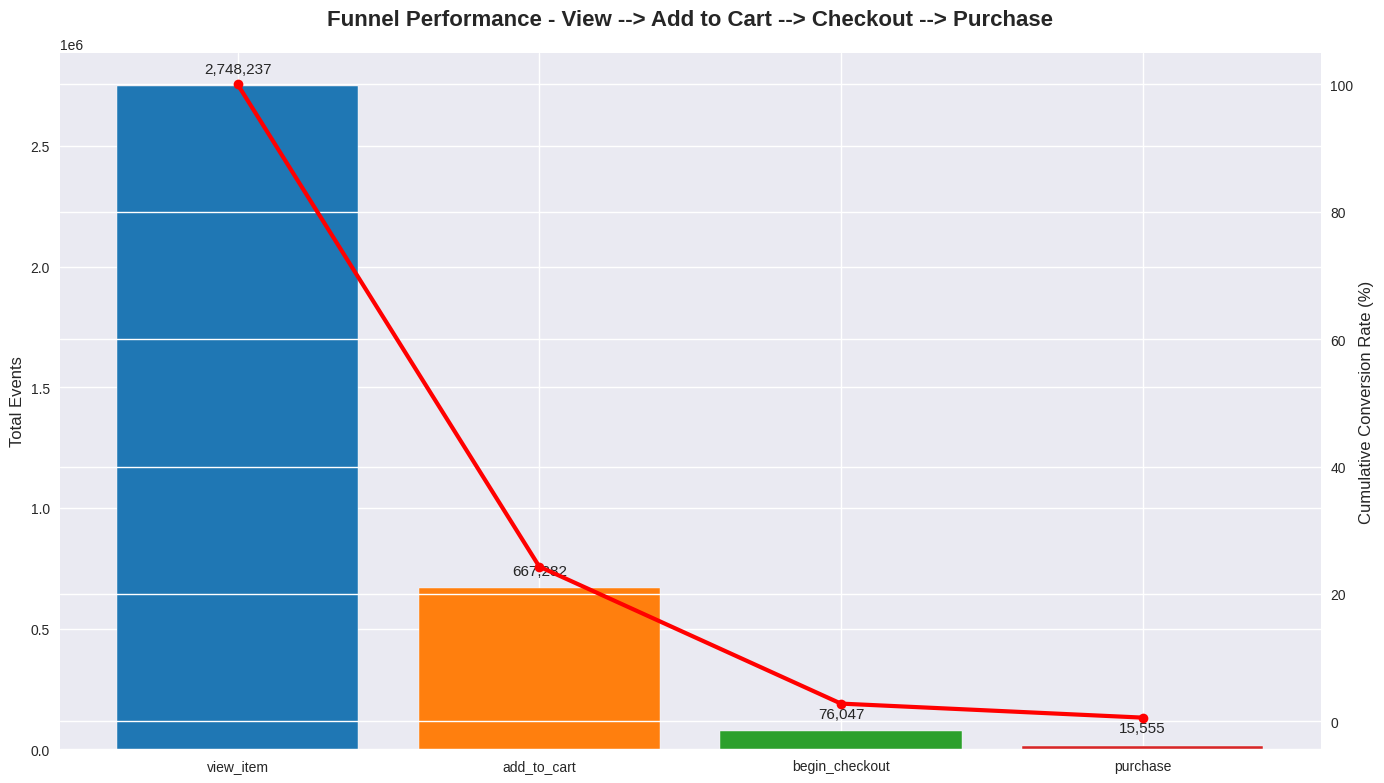

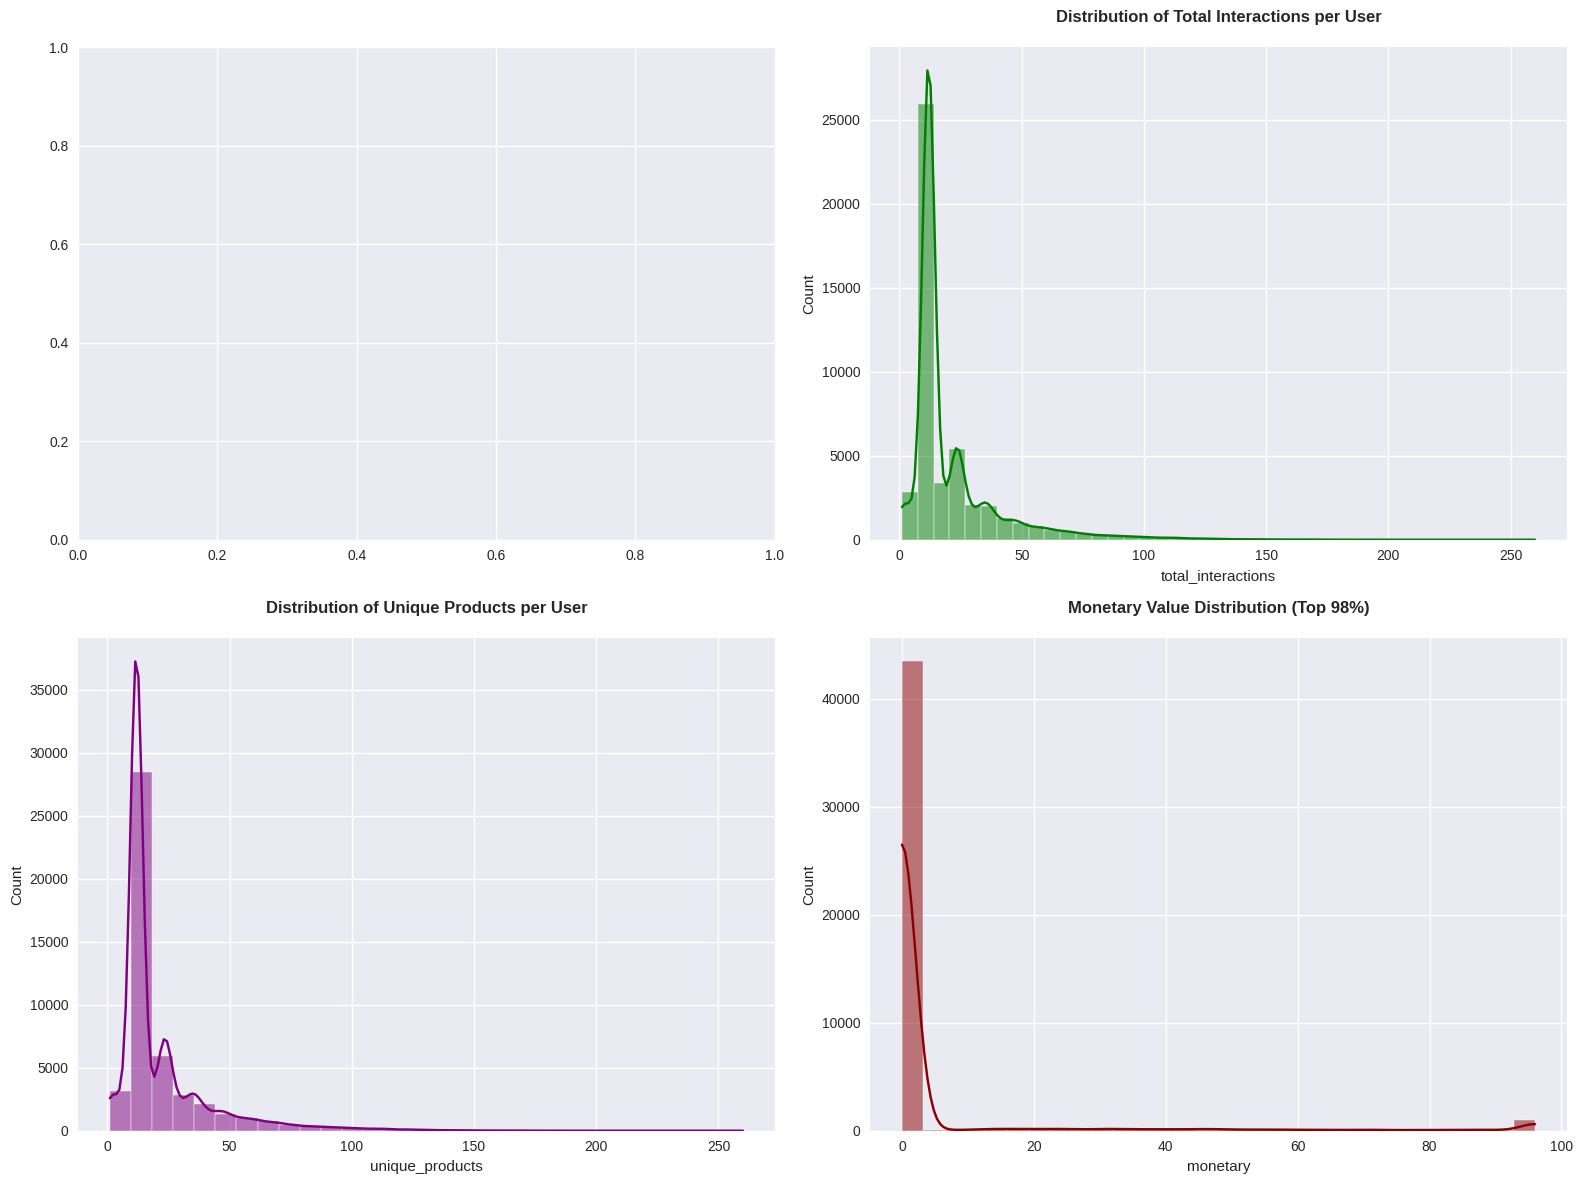

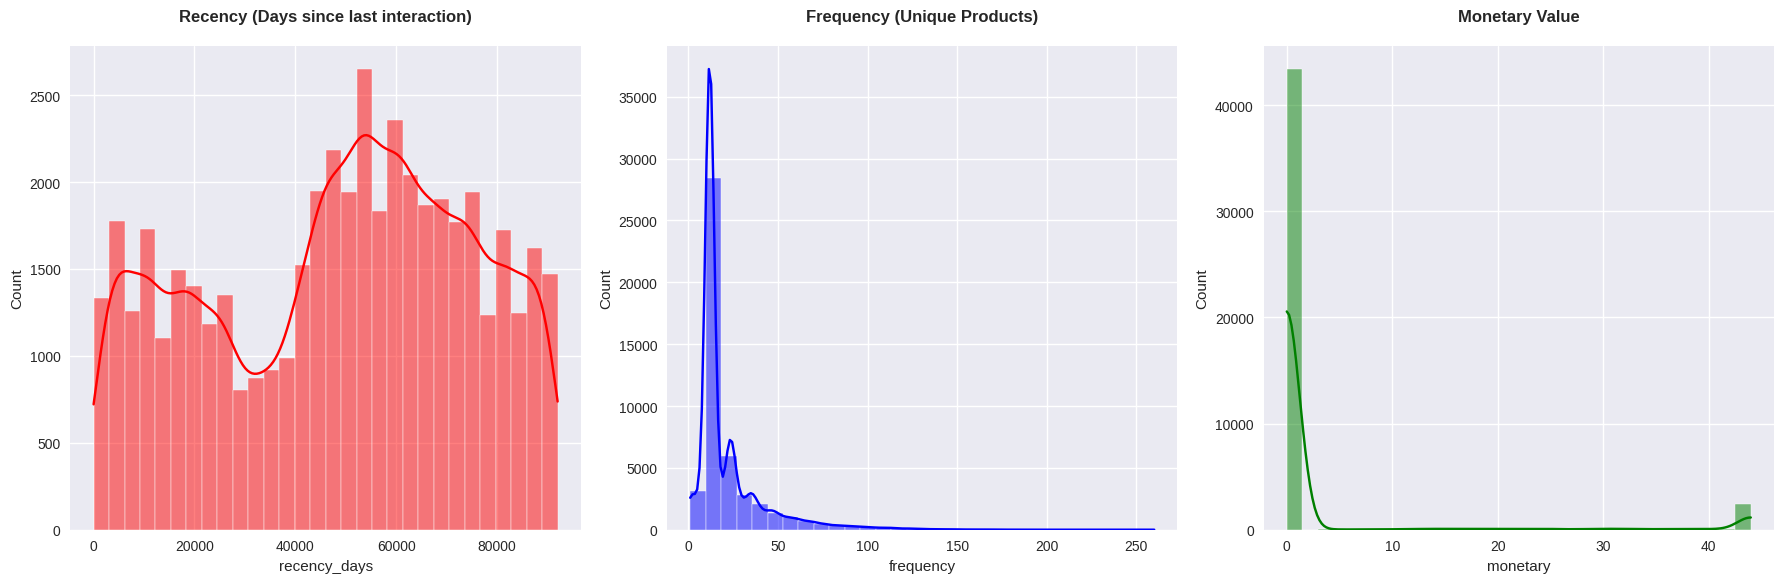

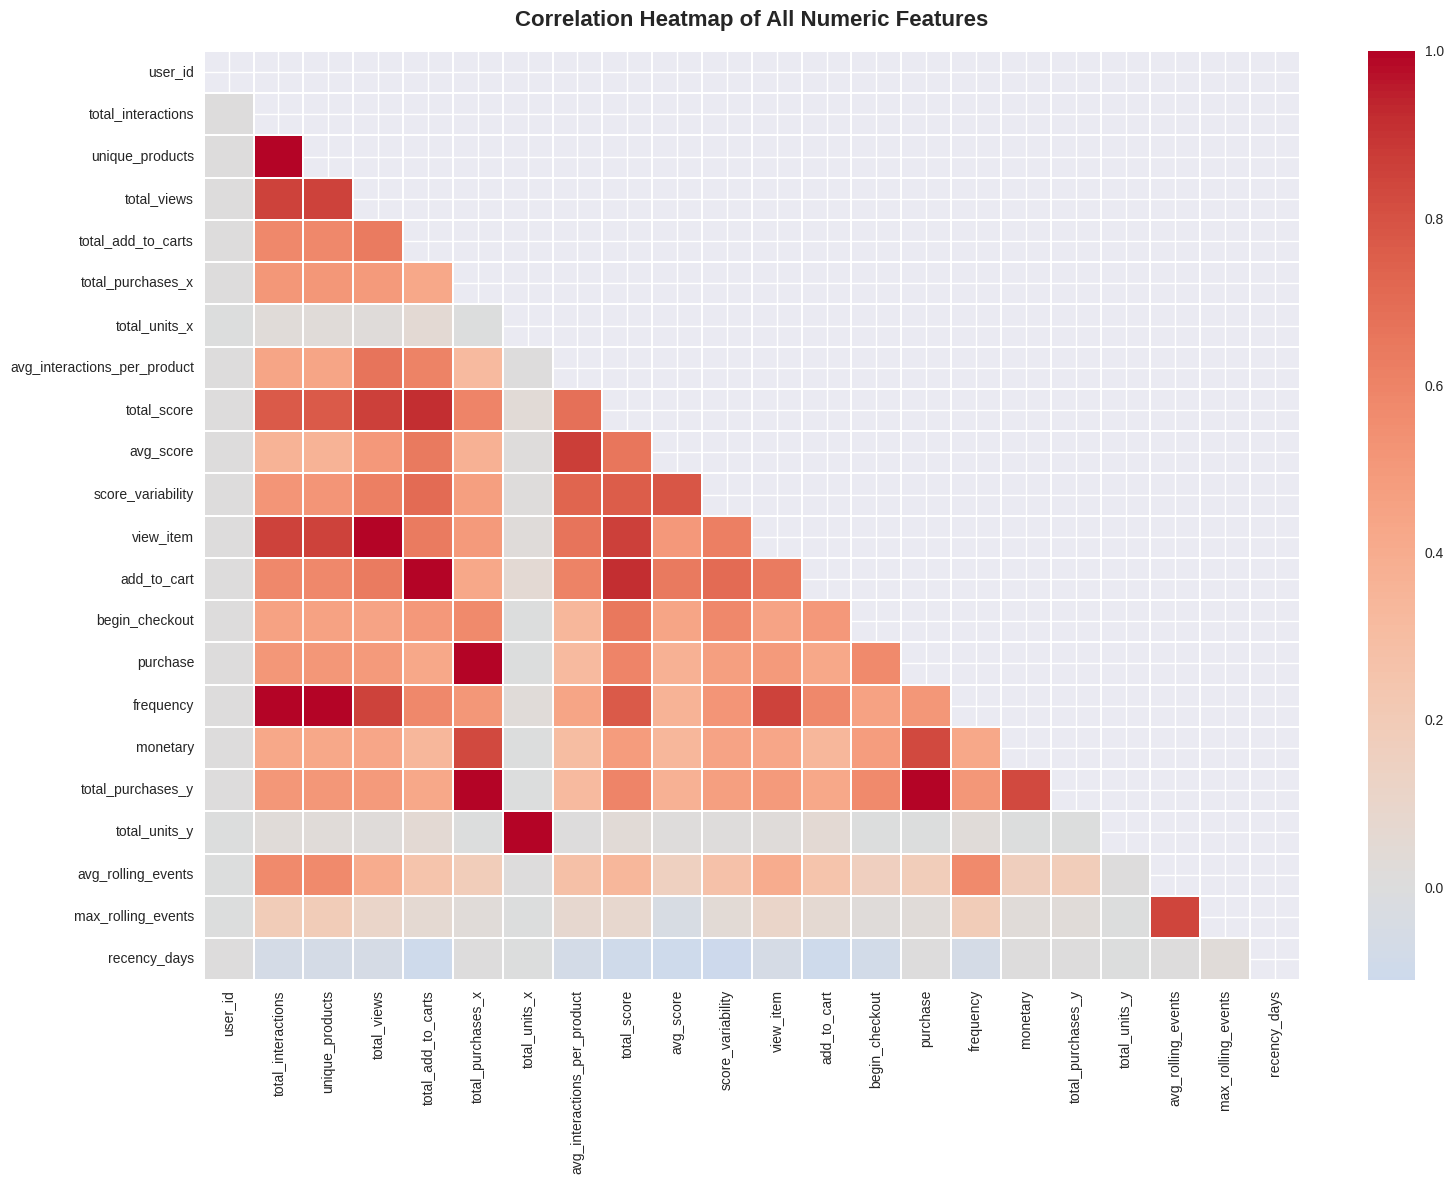

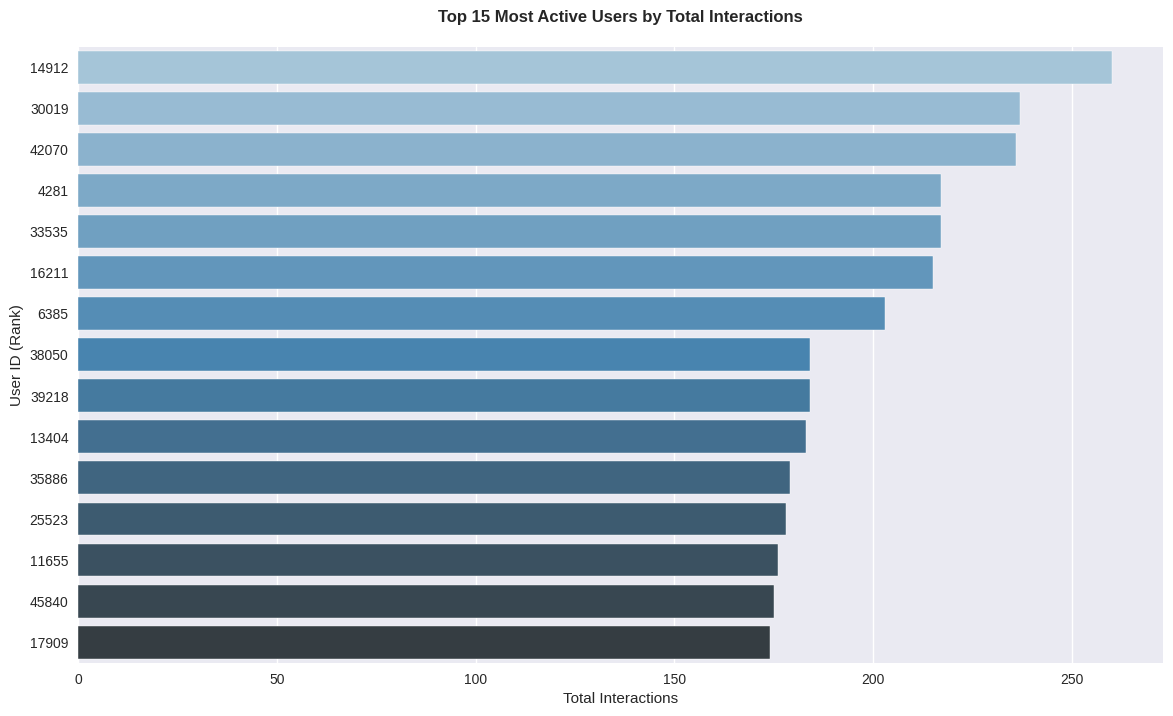

All interactive plots saved to: /content/ga4_interactive_plots/


Gen 1:   0%|          | 0/20 [00:00<?, ?it/s]

Gen 2:   0%|          | 0/20 [00:00<?, ?it/s]

Gen 3:   0%|          | 0/20 [00:00<?, ?it/s]

Gen 4:   0%|          | 0/20 [00:00<?, ?it/s]

...

<IPython.core.display.Javascript object>

Success: '/content/ga4_interactive_plots' compressed via LZMA and downloading.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Success: '/content/ga4_visualizations' compressed via LZMA and downloading.


In [ ]:
dbpath = '/content/drive/MyDrive/Colab Notebooks/ga4_obfuscated_ecommerce.duckdb'

if os.path.exists(dbpath):
    os.remove(dbpath)

MasterTrainData, final_features, connection = DataEngine_main(
        parquet_path           ='/content/drive/MyDrive/Colab Notebooks/ga4_obfuscated_sample_ecommerce.parquet',
        duckdb_path            = dbpath,
        run_genetic_selection  = True,
        generations            = 4,
        save_artifacts         = True,
        half_life_days         = 30.0)

In [ ]:
# ====================== CHECK RESULTS ======================
print("MasterTrainData (Detailed - Ready for FP-Growth + Collaborative Filtering)")
MasterTrainData.info()
print(f"Shape: {MasterTrainData.shape}")

print("\nfinal_features (User-level aggregates for funnel/analysis)")
final_features.info()
print(f"Shape: {final_features.shape}.\n")

# Quick preview
display(MasterTrainData.head(3))

print('\n\n')

display(final_features.head(3))

MasterTrainData (Detailed - Ready for FP-Growth + Collaborative Filtering)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014426 entries, 0 to 1014425
Data columns (total 52 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   user_id                              1014426 non-null  float64       
 1   product_id                           1014426 non-null  object        
 2   product_name                         1014426 non-null  object        
 3   department_id                        1005122 non-null  object        
 4   aisle_id                             1014426 non-null  object        
 5   brand                                1013847 non-null  object        
 6   category3                            1014426 non-null  object        
 7   avg_interaction_price                1014426 non-null  float64       
 8   view_count                           1014426 non-null  in

,user_id,product_id,product_name,department_id,aisle_id,brand,category3,avg_interaction_price,view_count,add_to_cart_count,...,event_timestamp,event_hour,event_day,event_month,event_dow,event_week,event_year,event_time_of_day,recency_days,decayed_interaction_score
0,6.662725e+07,GGOEGXXX1613,Super G Unisex Joggers,Home/New/,(not set),Google,(not set),37.0,4,0,...,2021-01-02 09:40:29.985,9,2,1,6,53,2021,Morning,29.59628,2.018743
1,6.662725e+07,GGCOGBJD157199,Google Land & Sea Tote Bag,Home/New/,(not set),(not set),(not set),20.0,4,1,...,2021-01-02 09:40:29.985,9,2,1,6,53,2021,Morning,29.59628,3.532800
2,6.662725e+07,GGCOGXXX1569,Google Land & Sea Unisex Tee,Home/New/,(not set),(not set),(not set),25.0,4,1,...,2021-01-02 09:40:29.985,9,2,1,6,53,2021,Morning,29.59628,3.532800


,user_id,score_variability,total_purchases_x,frequency,total_interactions,recency_days,unique_products,total_units_y,total_score,avg_score,total_views,total_units_x
0,6.662742e+06,0.000000,0.0,12,12,76310,12,12.0,12.0,1.000000,12.0,12.0
1,6.662928e+06,1.665151,0.0,45,45,85618,45,135.0,135.0,3.000000,135.0,135.0
2,6.663202e+07,0.404520,0.0,11,11,46718,11,24.0,24.0,2.181818,24.0,24.0


# Final Data Train Test

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import duckdb
import joblib
import os
import logging
from tqdm.auto import tqdm
import time
from copy import deepcopy
import warnings
import gc

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s"
)

logger = logging.getLogger(__name__)

In [ ]:
from pdb import set_trace

class DataTrainTest:
    def __init__(self,
                 MasterTrainData: pd.DataFrame = None,
                 DBconn: duckdb.DuckDBPyConnection = None,
                 encoder_dir: str = '/content/label_encoders/',
                 duckdb_path: str = '/content/drive/MyDrive/Colab Notebooks/ga4_obfuscated_ecommerce.duckdb'):
        self.duckdb_path = duckdb_path
        self.conn = DBconn
        self.FinalMasterData = None
        self.FinalMasterData_train = None
        self.FinalMasterData_test = None

        self.encoder_dir = encoder_dir
        os.makedirs(self.encoder_dir, exist_ok=True)

        self._connect()
        if MasterTrainData is not None:
            self.MasterTrainData = deepcopy(MasterTrainData)
        else:
            self.MasterTrainData = self.conn.execute("SELECT * FROM MasterTrainData").df()
        logger.info("DataTrainTest class initialized.")

    def _connect(self):
        if self.conn is not None:
            try:
                self.conn.execute("SELECT 1")
                return
            except:
                self.conn.close()

        self.conn = duckdb.connect(self.duckdb_path)
        logger.info(f"DuckDB connection opened again: {self.duckdb_path}")
        _tmp = self.conn.execute("SHOW TABLES;").df()
        logger.warning(f'Here is the table list:\n{_tmp}\n')

    def _fill_missing_categoricals(self):
        with tqdm(total=4, desc="Filling missing categoricals", colour="#14c44f") as pbar:
            cols = ['department_id', 'aisle_id', 'brand', 'category3']
            #set_trace()
            for col in cols:
                if col in self.MasterTrainData.columns.tolist():
                    self.MasterTrainData[col] = self.MasterTrainData[col].fillna('not_set').astype(str)
                    pbar.update(1)
        logger.info("Missing categorical values filled with 'not_set'")

    def _create_time_differences(self):
        with tqdm(total=5, desc="Creating time duration features", colour="#0a8032") as pbar:
            for col in ['last_interaction_date_gmt9', 'first_interaction_date_gmt9',
                       'last_interaction_time_gmt9', 'first_interaction_time_gmt9']:
                if col in self.MasterTrainData.columns.tolist():
                    self.MasterTrainData[col] = pd.to_datetime(self.MasterTrainData[col], errors='coerce')
                    pbar.update(1)

            self.MasterTrainData['user_product_look_days'] = (
                self.MasterTrainData['last_interaction_date_gmt9'] -
                self.MasterTrainData['first_interaction_date_gmt9']
            ).dt.days.fillna(0).astype('int32')

            self.MasterTrainData['user_product_look_hours'] = (
                (self.MasterTrainData['last_interaction_date_gmt9'] -
                 self.MasterTrainData['first_interaction_date_gmt9']).dt.days * 24
            ).fillna(0).astype('int32')
            pbar.update(1)

        logger.info("Time duration features created")

    def _label_encode_columns(self):
        cols_to_encode = [
            'product_name', 'department_id', 'aisle_id', 'brand', 'category3',
            'event_time_of_day', 'primary_device_category', 'primary_country',
            'primary_traffic_source'
        ]
        cols_to_encode = [col for col in cols_to_encode if col in self.MasterTrainData.columns]

        self.encoders = dict()

        for col in tqdm(cols_to_encode, desc="Label Encoding columns", colour="#258044"):
            le = LabelEncoder()
            self.MasterTrainData[col] = le.fit_transform(self.MasterTrainData[col].astype(str)).astype('int32')
            self.encoders[col] = le
            joblib.dump(le, f'{self.encoder_dir}{col}_encoder.joblib')

            mapping_df = pd.DataFrame({'original': le.classes_, 'encoded': range(len(le.classes_))})
            self.conn.execute(f"CREATE OR REPLACE TABLE mapping_{col} AS SELECT * FROM mapping_df")

        logger.info(f"{len(cols_to_encode)} columns label-encoded to int32")

    def _clean_columns(self):
        drop_cols = [
            'last_interaction_ts', 'first_interaction_ts', 'product_name', 'event_timestamp', 'event_year',
            'last_interaction_raw_unix_micros', 'last_interaction_date_gmt9', 'first_interaction_date_gmt9',
            'last_interaction_time_gmt9', 'first_interaction_time_gmt9',
            'last_interaction_day_of_week_gmt9', 'last_interaction_hour_category_gmt9'
        ]
        self.MasterTrainData = self.MasterTrainData.drop(
            columns=[c for c in drop_cols if c in self.MasterTrainData.columns]
        )
        before = len(self.MasterTrainData)
        self.MasterTrainData = self.MasterTrainData.dropna(subset=['user_id', 'product_id']).reset_index(drop=True)
        logger.info("Columns cleaned")

    def _downcast_dtypes(self):
        x1 = list(self.MasterTrainData.select_dtypes('int64').columns)
        x2 = list(self.MasterTrainData.select_dtypes('float64').columns)
        x3 = len(x1) + len(x2)
        with tqdm(total=x3, desc="Downcasting data types", colour="#317348") as pbar:
            for col in x1:
                self.MasterTrainData[col] = self.MasterTrainData[col].astype('int32')
                pbar.update(1)

            for col in x2:
                self.MasterTrainData[col] = self.MasterTrainData[col].astype('float32')
                pbar.update(1)
        logger.info("Data types downcasted")

    def _train_test_split(self):
        self.FinalMasterData = self.MasterTrainData.copy()
        train_idx, test_idx = train_test_split(self.FinalMasterData.index, test_size=0.2, random_state=1990)
        self.FinalMasterData_train = self.FinalMasterData.loc[train_idx].reset_index(drop=True)
        self.FinalMasterData_test = self.FinalMasterData.loc[test_idx].reset_index(drop=True)
        logger.info(f"Train-Test split completed")

    def _save_to_duckdb(self):
        with tqdm(total=3, desc="Saving tables to DuckDB", colour="#38ba66") as pbar:
            # Register DataFrames as temporary tables
            self.conn.register("temp_FinalMasterData", self.FinalMasterData)
            self.conn.execute("CREATE OR REPLACE TABLE FinalMasterData AS SELECT * FROM temp_FinalMasterData")
            self.conn.commit()
            pbar.update(1)

            self.conn.register("temp_FinalMasterData_train", self.FinalMasterData_train)
            self.conn.execute("CREATE OR REPLACE TABLE FinalMasterData_train AS SELECT * FROM temp_FinalMasterData_train")
            self.conn.commit()
            pbar.update(1)

            self.conn.register("temp_FinalMasterData_test", self.FinalMasterData_test)
            self.conn.execute("CREATE OR REPLACE TABLE FinalMasterData_test AS SELECT * FROM temp_FinalMasterData_test")
            self.conn.commit()
            pbar.update(1)

        logger.info("All tables successfully saved to DuckDB (FinalMasterData, FinalMasterData_train, FinalMasterData_test)")

    def _closing(self, start_time):
        elapsed = time.time() - start_time
        logger.info("="*70)
        logger.warning("FINAL DATA PREPARATION PIPELINE COMPLETED SUCCESSFULLY")
        logger.warning(f"Total time            : {elapsed:.2f} seconds")
        logger.warning(f"FinalMasterData shape : {self.FinalMasterData.shape}")
        logger.warning(f"Train shape           : {self.FinalMasterData_train.shape}")
        logger.warning(f"Test shape            : {self.FinalMasterData_test.shape}")
        logger.info("="*70)

    def __call__(self):
        logger.info("="*70)
        logger.info("STARTING FINAL DATA PREPARATION PIPELINE")
        logger.info("="*70 + "\n")
        start_time = time.time()
        self._fill_missing_categoricals()
        self._create_time_differences()
        self._label_encode_columns()
        self._clean_columns()
        self._downcast_dtypes()
        self._train_test_split()
        self._save_to_duckdb()
        gc.collect()
        self._closing(start_time)
        return self

In [ ]:
processor = DataTrainTest(
    duckdb_path='/content/drive/MyDrive/Colab Notebooks/ga4_obfuscated_ecommerce.duckdb'
)

TrainTest = processor()

                    name
0        MasterTrainData
1   UserFeature_Analysis
2  fpgrowth_transactions



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Filling missing categoricals:   0%|          | 0/4 [00:00<?, ?it/s]

Creating time duration features:   0%|          | 0/5 [00:00<?, ?it/s]

Label Encoding columns:   0%|          | 0/9 [00:00<?, ?it/s]

Downcasting data types:   0%|          | 0/31 [00:00<?, ?it/s]

Saving tables to DuckDB:   0%|          | 0/3 [00:00<?, ?it/s]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
TrainTest.conn.execute("PRAGMA table_info(FinalMasterData)").fetchdf()

,cid,name,type,notnull,dflt_value,pk
0,0,user_id,FLOAT,False,None,False
1,1,product_id,VARCHAR,False,None,False
2,2,department_id,INTEGER,False,None,False
3,3,aisle_id,INTEGER,False,None,False
4,4,brand,INTEGER,False,None,False
5,5,category3,INTEGER,False,None,False
6,6,avg_interaction_price,FLOAT,False,None,False
7,7,view_count,INTEGER,False,None,False
8,8,add_to_cart_count,INTEGER,False,None,False
9,9,begin_checkout_count,INTEGER,False,None,False


In [ ]:
from copy import deepcopy
pd.set_option('display.max_columns', None)
mas_train = deepcopy(TrainTest.FinalMasterData_train)
display(mas_train.sample(7))

print('\n\n')

display(mas_train.info())

,user_id,product_id,department_id,aisle_id,brand,category3,avg_interaction_price,view_count,add_to_cart_count,begin_checkout_count,purchase_count,total_quantity,total_interaction_score,num_interactions_per_user_product,primary_device_category,primary_country,primary_traffic_source,num_sessions,total_user_interactions,user_purchase_events,user_total_units_purchased,user_unique_products,user_tenure_days,total_item_interactions,item_total_views,item_total_add_to_carts,item_total_checkouts,item_total_purchases,item_unique_users,item_total_units_sold,item_avg_price,interaction_duration_hours,event_hour,event_day,event_month,event_dow,event_week,event_time_of_day,recency_days,decayed_interaction_score,user_product_look_days,user_product_look_hours
214186,8676958.0,GGOEGXXX1082,31,0,1,0,88.0,5,6,0,0,11,23,11,1,105,4,1,450,1,1,73,0,1276,1086,190,0,0,466,0,81.153603,0,18,6,1,3,1,1,25.208641,12.846237,0,0
271812,94740056.0,GGOEACBA104599,38,0,1,0,3.0,1,0,0,0,1,1,1,0,105,1,1,48,0,0,35,0,48115,37988,10127,0,0,10009,0,2.999148,0,17,16,1,6,2,0,15.266632,0.702764,0,0
781886,28378340.0,GGOEGXXX1613,51,0,1,0,37.0,6,0,0,0,6,6,6,1,105,5,1,108,0,0,14,0,63567,52758,10809,0,0,14714,0,36.981060,0,13,1,11,0,44,0,91.454880,0.725208,0,0
245200,12278969.0,GGOEGBJC122399,48,0,1,0,11.0,2,0,0,0,2,2,2,1,0,1,1,24,0,0,12,0,14433,12929,1504,0,0,5038,0,10.998199,0,16,7,12,1,50,0,55.300800,0.557344,0,0
16662,83318376.0,GGOEGDBD132099,49,0,1,0,10.0,3,2,0,0,5,9,5,0,105,2,2,446,7,9,113,56,14259,11377,2882,0,0,3905,0,9.997616,0,20,2,12,3,49,1,60.161781,2.241606,0,0
165698,54016672.0,GGOEGABJ099599,50,0,1,0,20.0,2,0,0,0,2,2,2,1,43,0,1,156,0,0,62,0,22909,19658,3251,0,0,6862,0,19.998079,0,19,24,1,0,3,1,7.184226,1.694108,0,0
237797,77143784.0,GGOEGBJJ103799,48,0,1,0,75.0,2,0,0,0,2,2,2,0,105,1,1,120,0,0,47,0,11809,10515,1294,0,0,4296,0,74.991112,0,18,22,11,0,47,1,70.247826,0.394584,0,0





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811540 entries, 0 to 811539
Data columns (total 42 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   user_id                            811540 non-null  float32
 1   product_id                         811540 non-null  object 
 2   department_id                      811540 non-null  int32  
 3   aisle_id                           811540 non-null  int32  
 4   brand                              811540 non-null  int32  
 5   category3                          811540 non-null  int32  
 6   avg_interaction_price              811540 non-null  float32
 7   view_count                         811540 non-null  int32  
 8   add_to_cart_count                  811540 non-null  int32  
 9   begin_checkout_count               811540 non-null  int32  
 10  purchase_count                     811540 non-null  int32  
 11  total_quantity                     8

None

In [ ]:
mas_test = deepcopy(TrainTest.FinalMasterData_test)

# FP-Growth Models
---

## Cython Parts

In [7]:
%%writefile fpgrowth.pyx

# cython: boundscheck=False
# cython: wraparound=False
# cython: cdivision=True
# cython: language_level=3
# distutils: extra_compile_args = -fopenmp
# distutils: extra_link_args = -fopenmp

import numpy as np
cimport numpy as np
from libc.stdlib cimport malloc, free
from libc.stdio cimport fprintf, stderr
from cython.parallel cimport prange, parallel, threadid
from libcpp.unordered_map cimport unordered_map
from libcpp.vector cimport vector
from libcpp.utility cimport pair

ctypedef np.int64_t INT64_t

# ========================================
# 1. FAST PARALLEL FREQUENCY COUNT
# ========================================
cpdef dict cython_count_frequency_parallel(list transactions, int n_threads=8):
    cdef:
        dict freq = dict()
        list trans
        object item
        int i, n = len(transactions)
        int tid
        dict local_freqs[8]

    for i in range(min(n_threads, 8)):
        local_freqs[i] = dict()

    # Note: Using 'with gil' inside the loop to allow dictionary access
    # while still printing via fprintf
    with nogil, parallel(num_threads=n_threads):
        tid = threadid()
        fprintf(stderr, "Thread %d started frequency count\n", tid)

        for i in prange(n, schedule='dynamic', chunksize=100):
            with gil:
                trans = transactions[i]
                current_tid = threadid() % 8
                for item in trans:
                    if item in local_freqs[current_tid]:
                        local_freqs[current_tid][item] += 1
                    else:
                        local_freqs[current_tid][item] = 1

    for i in range(min(n_threads, 8)):
        for item, cnt in local_freqs[i].items():
            freq[item] = freq.get(item, 0) + cnt

    return freq


# ========================================
# 2. PARALLEL SORT TRANSACTIONS
# ========================================
cpdef list cython_sort_transactions_parallel(list transactions, dict freq, int n_threads=8):
    cdef:
        list sorted_trans = [None] * len(transactions)
        int i, n = len(transactions)
        int tid

    with nogil, parallel(num_threads=n_threads):
        tid = threadid()
        fprintf(stderr, "Thread %d sorting batch...\n", tid)

        for i in prange(n, schedule='dynamic', chunksize=50):
            with gil:
                trans = transactions[i]
                filtered = [x for x in trans if x in freq]
                filtered.sort(key=lambda x: freq[x], reverse=True)
                sorted_trans[i] = filtered

    return sorted_trans


# ========================================
# 3. PARALLEL FP-TREE BUILD
# ========================================
cpdef dict cython_build_tree_parallel(list transactions, int n_threads=4):
    cdef:
        dict root = {"_count": 0, "_child": dict()}
        int i, n = len(transactions)
        int tid

    with nogil, parallel(num_threads=n_threads):
        tid = threadid()
        fprintf(stderr, "Thread %d building tree branch...\n", tid)

        for i in prange(n, schedule='dynamic', chunksize=20):
            with gil:
                trans = transactions[i]
                current = root
                for item in trans:
                    if item not in current["_child"]:
                        current["_child"][item] = {"_count": 1, "_child": {}}
                    else:
                        current["_child"][item]["_count"] += 1
                    current = current["_child"][item]

    root["_count"] = n
    return root

Writing fpgrowth.pyx


In [8]:
# from setuptools import setup
# from Cython.Build import cythonize
# import numpy as np

# setup(
#     script_args=['build_ext', '--inplace'],
#     ext_modules=cythonize(
#         "./fpgrowth.pyx",
#         compiler_directives={'language_level': "3"}
#     ),
#     include_dirs=[np.get_include()]
# )

In [9]:
%%writefile fpgrowth_core.pyx

# cython: language_level=3
# cython: boundscheck=False
# cython: wraparound=False
# cython: cdivision=True
# cython: initializedcheck=False
# cython: nonecheck=False

from libc.stdlib cimport malloc, free
from libc.stdio cimport fprintf, stderr
from cython.parallel cimport prange, parallel, threadid
cimport numpy as np
import numpy as np
np.import_array()
import cython

cdef class CTreeNode:
    cdef public int item_id
    cdef public int count
    cdef public CTreeNode parent
    cdef public dict children
    cdef public CTreeNode next_same_item

    def __cinit__(self, int item_id=-1, int count=0, CTreeNode parent=None):
        self.item_id = item_id
        self.count = count
        self.parent = parent
        self.children = dict()
        self.next_same_item = None


cdef class CFPTree:
    cdef public dict header_table
    cdef public dict frequent_items
    cdef public dict item_to_id
    cdef public list id_to_item
    cdef public float min_support
    cdef CTreeNode root
    cdef int num_frequent_items

    def __cinit__(self, dict frequent_items, float min_support):
        self.root = CTreeNode()
        self.frequent_items = frequent_items
        self.min_support = min_support

        sorted_items = sorted(frequent_items.keys(), key=lambda x: frequent_items[x], reverse=True)
        self.item_to_id = {item: idx for idx, item in enumerate(sorted_items)}
        self.id_to_item = sorted_items
        self.num_frequent_items = len(sorted_items)

        self.header_table = {item: None for item in sorted_items}

        fprintf(stderr, "DEBUG [CFPTree init] Created %d item IDs, min_support=%.4f\n",
                self.num_frequent_items, min_support)

    # ----------------------------------------------------------------
    # Helper: list[str] --> temporary C intlist() array
    # ----------------------------------------------------------------
    cdef int* _convert_transaction_to_carray(self, list transaction, int* length):
        length[0] = 0
        if not transaction:
            return NULL

        cdef int n = len(transaction)
        cdef int* carray = <int*> malloc(n * sizeof(int))
        if carray == NULL:
            return NULL

        cdef int i, item_id
        cdef str item
        for i in range(n):
            item = <str>transaction[i]
            item_id = self.item_to_id.get(item, -1)
            if item_id != -1:
                carray[length[0]] = item_id
                length[0] += 1
        return carray

    # ----------------------------------------------------------------
    # Step 3: INSERT (parallel-called)
    # ----------------------------------------------------------------
    cpdef void insert_transaction(self, list transaction):
        fprintf(stderr, "DEBUG [insert_transaction] Thread %d | transaction len=%d\n",
                threadid(), len(transaction))

        cdef int length = 0
        cdef int* carray = self._convert_transaction_to_carray(transaction, &length)
        if carray == NULL or length == 0:
            if carray != NULL:
                free(carray)
            return

        cdef int i, j, tmp
        for i in range(length):
            for j in range(i + 1, length):
                if self.frequent_items[self.id_to_item[carray[i]]] < self.frequent_items[self.id_to_item[carray[j]]]:
                    tmp = carray[i]
                    carray[i] = carray[j]
                    carray[j] = tmp

        cdef CTreeNode current = self.root
        cdef CTreeNode new_node
        cdef CTreeNode last
        cdef int item_id
        cdef str item_str

        for i in range(length):
            item_id = carray[i]
            item_str = self.id_to_item[item_id]
            if item_str not in current.children:
                new_node = CTreeNode(item_id, 1, current)
                current.children[item_str] = new_node
                if self.header_table[item_str] is None:
                    self.header_table[item_str] = new_node
                else:
                    last = self.header_table[item_str]
                    while last.next_same_item is not None:
                        last = last.next_same_item
                    last.next_same_item = new_node
            else:
                (<CTreeNode>current.children[item_str]).count += 1
            current = <CTreeNode>current.children[item_str]

        free(carray)
        fprintf(stderr, "DEBUG [insert_transaction] Thread %d | insert finished\n", threadid())

    # PARALLEL build (your main heavy loop)
    cpdef void build_from_transactions(self, list transactions):
        fprintf(stderr, "DEBUG [build_from_transactions] Starting PARALLEL build | %d transactions\n",
                len(transactions))

        cdef int n = len(transactions)
        cdef int i

        with nogil, parallel():
            for i in prange(n, schedule='dynamic', chunksize=1000):
                with gil:
                    self.insert_transaction(transactions[i])

        fprintf(stderr, "DEBUG [build_from_transactions] PARALLEL build completed\n")

    cpdef void update(self, list new_transactions):
        fprintf(stderr, "DEBUG [update] Incremental/Streaming update | %d transactions\n",
                len(new_transactions))
        self.build_from_transactions(new_transactions)

    # ----------------------------------------------------------------
    # Step 4: MINING (sequential + full fprintf debugging)
    # ----------------------------------------------------------------
    cpdef void mine_frequent_itemsets(self, list prefix, int min_support_count, dict frequent_itemsets):
        fprintf(stderr, "DEBUG [mine_frequent_itemsets] Starting mining | prefix len=%d\n", len(prefix))

        cdef list items_to_process = list(self.header_table.keys())
        items_to_process.reverse()
        cdef int num_items = len(items_to_process)
        cdef int i
        cdef str item
        cdef int support_count
        cdef CTreeNode node
        cdef list cond_patterns
        cdef CFPTree cond_tree
        cdef bytes bitem   # safe bytes for fprintf

        for i in range(num_items):
            item = items_to_process[i]
            bitem = item.encode('utf-8')
            fprintf(stderr, "DEBUG [mine] Thread %d | Processing item %s (%d/%d)\n",
                    threadid(), <char*>bitem, i + 1, num_items)

            support_count = 0
            node = self.header_table.get(item)
            while node is not None:
                support_count += node.count
                node = node.next_same_item

            if support_count >= min_support_count:
                new_itemset = frozenset(prefix + [item])
                frequent_itemsets[new_itemset] = support_count

            cond_patterns = self.get_conditional_pattern_base(item)
            cond_tree = self._build_conditional_tree(cond_patterns, min_support_count)

            if cond_tree is not None and cond_tree.root.children:
                cond_tree.mine_frequent_itemsets(prefix + [item], min_support_count, frequent_itemsets)

        fprintf(stderr, "DEBUG [mine_frequent_itemsets] Mining finished\n")

    # ----------------------------------------------------------------
    # Helpers
    # ----------------------------------------------------------------
    cpdef list get_conditional_pattern_base(self, str item):
        cdef bytes bitem = item.encode('utf-8')
        fprintf(stderr, "DEBUG [get_conditional_pattern_base] Item %s\n", <char*>bitem)

        cdef list patterns = list()
        cdef CTreeNode node = self.header_table.get(item)
        if node is None:
            return patterns
        cdef list path
        cdef CTreeNode parent
        while node is not None:
            path = list()
            parent = node.parent
            while parent is not None and parent.item_id != -1:
                path.append(self.id_to_item[parent.item_id])
                parent = parent.parent
            if path:
                patterns.append((path[::-1], node.count))
            node = node.next_same_item
        return patterns

    cpdef CFPTree _build_conditional_tree(self, list conditional_patterns, int min_support_count):
        if not conditional_patterns:
            return None
        fprintf(stderr, "DEBUG [_build_conditional_tree] Building for %d patterns\n",
                len(conditional_patterns))

        cdef dict cond_item_count = dict()
        cdef list path
        cdef int count
        cdef list sorted_path
        cdef CTreeNode current
        cdef CTreeNode new_node
        cdef CTreeNode last
        cdef str item
        cdef int i, j
        cdef str tmp_item

        for path, count in conditional_patterns:
            for item in path:
                if item in cond_item_count:
                    cond_item_count[item] += count
                else:
                    cond_item_count[item] = count

        cdef dict cond_frequent = {item: cnt for item, cnt in cond_item_count.items() if cnt >= min_support_count}
        if not cond_frequent:
            return None

        cdef CFPTree cond_tree = CFPTree(cond_frequent, 0.0)

        for path, count in conditional_patterns:
            sorted_path = [item for item in path if item in cond_frequent]
            if not sorted_path:
                continue

            # Manual bubble sort (no lambda)
            for i in range(len(sorted_path)):
                for j in range(i + 1, len(sorted_path)):
                    if cond_frequent[sorted_path[i]] < cond_frequent[sorted_path[j]]:
                        tmp_item = sorted_path[i]
                        sorted_path[i] = sorted_path[j]
                        sorted_path[j] = tmp_item

            current = cond_tree.root
            for item in sorted_path:
                if item not in current.children:
                    new_node = CTreeNode(cond_tree.item_to_id[item], count, current)
                    current.children[item] = new_node
                    if cond_tree.header_table[item] is None:
                        cond_tree.header_table[item] = new_node
                    else:
                        last = cond_tree.header_table[item]
                        while last.next_same_item is not None:
                            last = last.next_same_item
                        last.next_same_item = new_node
                else:
                    (<CTreeNode>current.children[item]).count += count
                current = <CTreeNode>current.children[item]
        return cond_tree


# --------------------------------------------------------------------
# Prediction (simple + fprintf)
# --------------------------------------------------------------------
cpdef list c_predict_one(list trans, dict frequent_itemsets):
    # Convert trans to a set for O(1) lookup speed in .issubset()
    cdef object trans_set = set(trans)

    if not frequent_itemsets:
        return list()

    cdef np.ndarray keys = np.array(list(frequent_itemsets.keys()), dtype=object)
    cdef np.ndarray vals = np.array(list(frequent_itemsets.values()), dtype=np.int32)
    cdef int n = len(keys)
    cdef list matches = list()
    cdef int i
    cdef object current_key

    for i in prange(n, nogil=True, schedule='static'):
        with gil:
            current_key = keys[i]
            if current_key.issubset(trans_set):
                matches.append((current_key, vals[i]))

    return matches[:10]

Writing fpgrowth_core.pyx


In [10]:
%%writefile setup.py

from setuptools import setup, Extension
from Cython.Build import cythonize
import numpy as np

ext_modules = [
    Extension(
        "fpgrowth_core",
        sources=["./fpgrowth_core.pyx"],
        include_dirs=[np.get_include()],
        extra_compile_args=['-fopenmp'],  # CRITICAL for prange
        extra_link_args=['-fopenmp'],     # CRITICAL for prange
        annotate=True,
        quiet=True,
    )
]

setup(
    ext_modules=cythonize(ext_modules, language_level=3, annotate=True),
    zip_safe=False,
)

Writing setup.py


In [11]:
!python3 setup.py build_ext --inplace

/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/extension.py:139: UserWarning: Unknown Extension options: 'annotate', 'quiet'
  warnings.warn(msg)
Compiling ./fpgrowth_core.pyx because it changed.
[1/1] Cythonizing ./fpgrowth_core.pyx
running build_ext
building 'fpgrowth_core' extension
creating build/temp.linux-x86_64-cpython-312
x86_64-linux-gnu-gcc -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g -fwrapv -O2 -fPIC -I/usr/local/lib/python3.12/dist-packages/numpy/_core/include -I/usr/include/python3.12 -c ./fpgrowth_core.c -o build/temp.linux-x86_64-cpython-312/./fpgrowth_core.o -fopenmp
In file included from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarraytypes.h:1909,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/arrayobject.

In [12]:
%%writefile clookfor_frequent_items.pyx

# cython: boundscheck=False
# cython: wraparound=False
# cython: nonecheck=False
# cython: cdivision=True
# cython: initializedcheck=False
# cython: language_level=3

from cython.parallel import prange
from libcpp.unordered_map cimport unordered_map
from libcpp.vector cimport vector
from libcpp.string cimport string
from libc.stdio cimport fprintf, stdout, stderr
import cython
import os

ctypedef unordered_map[string, long] counter_map

@cython.boundscheck(False)
@cython.wraparound(False)
cpdef dict clookfor_frequent_items(
        list transactions,
        double min_support,
        int n_jobs=-1
    ):
    # -----------------------------------------
    # Initialized any of variable
    # -----------------------------------------
    cdef:
        Py_ssize_t i, j
        Py_ssize_t num_transactions
        Py_ssize_t min_count
        int n_threads

    fprintf(stdout, b"[DEBUG] Starting clookfor_frequent_items\n")
    num_transactions = len(transactions)
    fprintf(stdout, b"[DEBUG] Number transactions: %ld\n", num_transactions)
    if n_jobs == -1:
        n_threads = os.cpu_count()
    else:
        n_threads = n_jobs

    fprintf(stdout, b"[DEBUG] Using threads: %d\n", n_threads)
    min_count = <Py_ssize_t>(min_support * num_transactions)
    fprintf(stdout, b"[DEBUG] Min support count: %ld\n", min_count)

    # -----------------------------------------
    # Convert Python transactions to C++ vector
    # -----------------------------------------
    fprintf(stdout, b"[DEBUG] Converting transactions to C++ vector\n")
    cdef vector[vector[string]] c_transactions
    cdef vector[string] c_transaction
    cdef string item

    for i in range(num_transactions):
        c_transaction.clear()
        for j in range(len(transactions[i])):
            item = (<str>transactions[i][j]).encode("utf8")
            c_transaction.push_back(item)
        c_transactions.push_back(c_transaction)
        if i % 100000 == 0:
            fprintf(stdout, b"[DEBUG] Converted %ld transactions\n", i)
    fprintf(stdout, b"[DEBUG] Conversion complete\n")

    # -----------------------------------------
    # Thread counters
    # -----------------------------------------
    fprintf(stdout, b"[DEBUG] Allocating thread counters\n")
    cdef vector[counter_map] thread_counters
    thread_counters.resize(n_threads)

    # -----------------------------------------
    # Parallel counting
    # -----------------------------------------
    fprintf(stdout, b"[DEBUG] Starting parallel counting\n")
    cdef int thread_id
    with nogil:
        for i in prange(num_transactions, schedule='dynamic', num_threads=n_threads):
            thread_id = i % n_threads
            for j in range(c_transactions[i].size()):
                thread_counters[thread_id][c_transactions[i][j]] += 1
    fprintf(stdout, b"[DEBUG] Parallel counting finished\n")

    # -----------------------------------------
    # Merge counters
    # -----------------------------------------
    fprintf(stdout, b"[DEBUG] Merging counters\n")
    cdef counter_map global_counter
    for i in range(n_threads):
        for pair in thread_counters[i]:
            global_counter[pair.first] += pair.second
    fprintf(stdout, b"[DEBUG] Merge complete\n")

    # -----------------------------------------
    # Filter frequent
    # -----------------------------------------
    fprintf(stdout, b"[DEBUG] Filtering frequent items\n")
    cdef dict result = {}
    cdef string k
    cdef long v
    for pair in global_counter:
        k = pair.first
        v = pair.second
        if v >= min_count:
            result[k.decode("utf8")] = v
    fprintf(stdout, b"[DEBUG] Frequent items found: %ld\n", len(result))
    fprintf(stdout, b"[DEBUG] Finished\n")
    return result

Writing clookfor_frequent_items.pyx


In [13]:
%%writefile clookfor_setup.py

from setuptools import setup, Extension
from Cython.Build import cythonize
import numpy
import os

extensions = [
    Extension(
        "frequent_items",
        ["clookfor_frequent_items.pyx"],
        extra_compile_args=[
            "-O3",
            "-march=native",
            "-ffast-math",
            "-fopenmp"
        ],
        extra_link_args=["-fopenmp"],
        language="c++"
    )]

setup(ext_modules=cythonize(
    extensions,
    compiler_directives={
            'language_level': "3",
            'boundscheck': False,
            'wraparound': False,
            'cdivision': True
        }),
    include_dirs=[numpy.get_include()])

Writing clookfor_setup.py


In [14]:
!python3 clookfor_setup.py build_ext --inplace

Compiling clookfor_frequent_items.pyx because it changed.
[1/1] Cythonizing clookfor_frequent_items.pyx
running build_ext
building 'frequent_items' extension
x86_64-linux-gnu-g++ -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g -fwrapv -O2 -fPIC -I/usr/local/lib/python3.12/dist-packages/numpy/_core/include -I/usr/include/python3.12 -c clookfor_frequent_items.cpp -o build/temp.linux-x86_64-cpython-312/clookfor_frequent_items.o -O3 -march=native -ffast-math -fopenmp
clookfor_frequent_items.cpp: In function ‘PyObject* __pyx_f_14frequent_items_clookfor_frequent_items(PyObject*, double, int, __pyx_opt_args_14frequent_items_clookfor_frequent_items*)’:
clookfor_frequent_items.cpp:3292:61: warning: comparison of integer expressions of different signedness: ‘Py_ssize_t’ {aka ‘long int’} and ‘std::vector<std::__cxx11::basic_string<char> >::size_type’ {aka ‘long unsigned int’} []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning

## FPGrowth API
---

In [15]:
import pandas as pd
import numpy as np
import json
import logging
import gc
from typing import List, Dict, Tuple, Optional, Any, FrozenSet
from collections import Counter
import os
from copy import deepcopy
from tqdm import tqdm
from joblib import Parallel, delayed
import warnings
import cloudpickle as pickle

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

# ====================== YOUR CYTHON IMPORT ======================
try:
    from fpgrowth_core import CFPTree, c_predict_one
    from frequent_items import clookfor_frequent_items
except ImportError:
    raise ImportError("Run 'python setup.py build_ext --inplace' first!")

In [16]:
def prepare_transactions(
        df: pd.DataFrame,
        group_by: str = 'user_id',
        item_col: str = 'product_id',
        filter_col: str = 'purchase_count',
        min_val: int = 1,
        unique: bool = True,
        chunk_size: Optional[int] = None
    ) -> List[List[str]]:
    logger.info(f"Preparing transactions from {len(df):,} rows.")
    assert isinstance(df, pd.DataFrame), 'Argument df is not dataframe in pandas.'
    Trans = df.copy()

    # Filter if column exists
    if filter_col.lower() not in [c.lower() for c in Trans.columns]:
        logger.warning(f'The {filter_col} column is not there!')
    else:
        Trans = Trans[Trans[filter_col] >= min_val]
        logger.info(f"After filtering {filter_col} >= {min_val}: {len(Trans):,} rows")

    # Group by user
    if chunk_size is not None and int(Trans.shape[0]) > chunk_size:
        transactions = list()
        for start in tqdm(range(0, len(Trans), chunk_size), desc="Chunking", colour='green'):
            chunk = Trans.iloc[start:start+chunk_size]
            chunk_trans = chunk.groupby(group_by)[item_col].apply(list).tolist()
            transactions.extend(chunk_trans)
    else:
        transactions = Trans.groupby(group_by)[item_col].apply(list).tolist()

    # Clean: unique items + string
    if unique:
        transactions = [list(dict.fromkeys(t)) for t in transactions]
    transactions = [[str(item) for item in t if pd.notna(item)] for t in transactions]

    logger.info(f"Prepared {len(transactions):,} transactions (one per user)")
    gc.collect()
    return transactions

def _count_in_chunk(chunk: List[List[str]]) -> Dict[str, int]:
    return dict(Counter(item for transaction in chunk for item in transaction))

In [17]:
from collections import Counter
from functools import reduce

def find_frequent_items(
    transactions: List[List[str]],
    min_support: float,
    n_jobs: int = -1
) -> Dict[str, int]:
    logger.info("Finding frequent 1-itemsets (parallel).")
    num_transactions = len(transactions)
    min_count = int(min_support * num_transactions)

    n_chunks = min(os.cpu_count() or 8, len(transactions))
    chunks = [transactions[i::n_chunks] for i in range(n_chunks)]

    chunk_counts_list: List[Dict] = Parallel(n_jobs=n_jobs)(
        delayed(_count_in_chunk)(chunk) for chunk in tqdm(chunks, desc="Counting", colour='green'))

    item_count: Dict[str, int] = dict()
    item_count = reduce(Counter.__add__, map(Counter, chunk_counts_list))
    # for chunk_count in chunk_counts_list:
    #     for item, cnt in chunk_count.items():
    #         item_count[item] = item_count.get(item, 0) + cnt

    frequent = {item: count for item, count in item_count.items() if count >= min_count}
    logger.info(f"Found {len(frequent)} frequent items")
    return frequent

In [18]:
def visualize_frequent_itemsets(
    frequent_itemsets: Dict[FrozenSet[str], int],
    output_dir: str = "."
) -> None:
    logger.info("Generating seaborn visualizations (saved, never shown)")
    os.makedirs(output_dir, exist_ok=True)
    data = [{'itemset': ' --> '.join(sorted(itemset)), 'support': supp, 'length': len(itemset)}
            for itemset, supp in frequent_itemsets.items()]
    vis_df = pd.DataFrame(data).sort_values('support', ascending=False)

    # Top 20
    plt.figure(figsize=(14, 8))
    sns.barplot(data=vis_df.head(20), x='support', y='itemset', palette='viridis')
    plt.title('Top 20 Frequent Itemsets')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'top_20_frequent_itemsets.png'), dpi=300, bbox_inches='tight')
    plt.close()

    # Length distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=vis_df, x='length', palette='viridis')
    plt.title('Itemset Length Distribution')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'itemset_length_distribution.png'), dpi=300, bbox_inches='tight')
    plt.close()
    gc.collect()

## PRODUCTION API

---

In [19]:
import duckdb
import pandas as pd
from typing import Optional, Union, List, Dict, Any, ContextManager
from pathlib import Path
from contextlib import contextmanager

class DuckDBManager:
    """
    Manager class for DuckDB connections and queries.

    Example:
        db = DuckDBManager('mydb.duckdb')
        df = db.query("SELECT * FROM users")
        db.close()

        # Or use context manager:
        with DuckDBManager('mydb.duckdb') as db:
            df = db.query("SELECT * FROM users")
    """

    def __init__(self,
                 db_path: Union[str, Path],
                 read_only: bool = True,
                 threads: Optional[int] = None,
                 memory_limit: Optional[str] = '2GB'):
        """
        Initialize DuckDB manager.

        Args:
            db_path: Path to database file (use ':memory:' for in-memory DB)
            read_only: Open in read-only mode
            threads: Number of CPU threads to use
            memory_limit: Memory limit (e.g., '4GB', '1TB')
        """
        self.db_path = str(db_path)
        self.read_only = read_only
        self.conn = None

        # Create connection
        self._create_connection(threads, memory_limit)

    def _create_connection(self, threads: Optional[int] = None,
                          memory_limit: Optional[str] = None):
        """Create DuckDB connection with optional settings."""
        self.conn = duckdb.connect(database=self.db_path, read_only=self.read_only)

        # Configure settings
        if threads:
            self.conn.execute(f"SET threads = {threads}")
        if memory_limit:
            self.conn.execute(f"SET memory_limit = '{memory_limit}'")

    def query(self,
              query: str,
              params: Optional[Union[List, Dict, tuple]] = None,
              fetch_size: Optional[int] = None) -> pd.DataFrame:
        """
        Execute query and return DataFrame.

        Args:
            query: SQL query string
            params: Query parameters
            fetch_size: Number of rows to fetch (None for all)

        Returns:
            pandas DataFrame
        """
        if self.conn is None:
            raise ValueError("Connection is closed. Please reconnect.")

        try:
            if params is not None:
                result = self.conn.execute(query, params)
            else:
                result = self.conn.execute(query)

            if fetch_size:
                return result.fetch_df_chunk(fetch_size)
            return result.fetchdf()

        except Exception as e:
            raise Exception(f"Query failed: {e}\nQuery: {query}")

    def query_arrow(self, query: str, params: Optional[Union[List, Dict]] = None):
        """Execute query and return Arrow table (faster for large datasets)."""
        if params is not None:
            return self.conn.execute(query, params).fetch_arrow_table()
        return self.conn.execute(query).fetch_arrow_table()

    def register_dataframe(self, name: str, df: pd.DataFrame):
        """Register pandas DataFrame as temporary table (table_view)."""
        self.conn.register(name, df)

    def ListedTable(self):
        tables = self.conn.execute("SELECT table_name FROM duckdb_tables()").df()
        data = list()
        for table in tables['table_name']:
            count = self.conn.execute(f"SELECT count(*) FROM {table}").fetchone()[0]
            data.append({'table_name': table, 'row_count': count})
        info_df = pd.DataFrame(data)
        info_df = info_df.sort_values(by='row_count', ascending=False)
        info_df['row_count'] = info_df['row_count'].apply(lambda x: f"{x:,}")
        display(info_df)
        return info_df

    def execute(self, query: str, params: Optional[Union[List, Dict]] = None):
        """Execute query without returning results."""
        if params is not None:
            self.conn.execute(query, params)
        else:
            self.conn.execute(query)

    def table_exists(self, table_name: str) -> bool:
        """Check if table exists in database."""
        result = self.query(
            "SELECT COUNT(*) FROM information_schema.tables WHERE table_name = ?",
            [table_name]
        )
        return result.iloc[0, 0] > 0

    def get_tables(self) -> List[str]:
        """Get list of all tables in database."""
        df = self.query("SELECT table_name FROM information_schema.tables WHERE table_schema = 'main'")
        return df['table_name'].tolist()

    def get_schema(self, table_name: str) -> pd.DataFrame:
        """Get schema information for a table."""
        return self.query(f"DESCRIBE {table_name}")

    def close(self):
        """Close database connection."""
        if self.conn:
            self.conn.close()
            self.conn = None

    def __enter__(self):
        """Context manager entry."""
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        """Context manager exit."""
        self.close()

@contextmanager
def duckdb_connection(db_path: Union[str, Path],
                      read_only: bool = False,
                      **kwargs) -> DuckDBManager:
    """
    Context manager for DuckDB connection.

    Example:
        with duckdb_connection('mydb.duckdb') as db:
            df = db.query("SELECT * FROM users")
    """
    db = DuckDBManager(db_path, read_only, **kwargs)
    try:
        yield db
    finally:
        db.close()

In [20]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from itertools import islice

class FPGrowthAPI:
    def __init__(self, min_support: float = 0.01, **kwargs):
        self.min_support = min_support
        self.frequent_itemsets: Optional[Dict] = None
        self.tree: Optional[CFPTree] = None
        self.total_transactions: int = 0
        self._TestData = pd.DataFrame({})
        self.variant = kwargs.get('variant', 'full')

    def __repr__(self):
        return f'FPGrowthAPI {str(self.__init__)}.\n'

    @property
    def TestData(self) :
        return self._TestData

    @TestData.setter
    def TestData(self, values : pd.DataFrame) :
        try :
            assert isinstance(values, pd.DataFrame), (
                   'The argument for model is not a dataframe.'
                   )
            assert not values.empty, (
                   'The dataframe is empty.'
                   )
            self._TestData     = values
        except Exception as Arch :
            Warn            = f'''
    [TestData ERROR] We can not get the Test Data callable from Argument.
    [TestData ERROR] Failure : {Arch}
            '''
            logger.warning(Warn)

    def fit(self, df: pd.DataFrame, **kwargs):
        if self.variant == 'full':
            self._fit_full(df, **kwargs)

    def _fit_full(self, df: pd.DataFrame, **kwargs):
        logger.info("=== FULL FP-Growth ===")

        # Extract output_dir for visualization and remove it from kwargs for prepare_transactions
        output_dir_for_viz = kwargs.pop('output_dir', '.')

        transactions = prepare_transactions(df, **kwargs)
        self.total_transactions = len(transactions)

        try:
            frequent_1 = clookfor_frequent_items(transactions,
                                                 self.min_support,
                                                 n_jobs = -1,
                                                 )
        except Exception as Arch:
            logger.warning(f'Can not get the frequent item from C++ function: {Arch}')
            frequent_1 = find_frequent_items(transactions, self.min_support)

        if not frequent_1:
            logger.warning("No frequent items found")
            return

        self.tree = CFPTree(frequent_1, self.min_support)
        self.tree.build_from_transactions(transactions)

        min_count = int(self.min_support * self.total_transactions)
        self.frequent_itemsets = dict()
        self.tree.mine_frequent_itemsets(list(), min_count, self.frequent_itemsets)

        visualize_frequent_itemsets(self.frequent_itemsets, output_dir_for_viz)
        gc.collect()
        logger.info(f"Mining finished - {len(self.frequent_itemsets)} frequent itemsets")

    def _predict_row(self,
                    row,
                    top_k: int,
                    min_support_threshold: float,
                    INVALID):
        current_user_id = str(row.user_id)
        items_for_prediction = row.items

        # Clean items
        items_for_prediction = [cleaned
            for item in items_for_prediction
            if (cleaned := str(item).strip()).lower() not in INVALID]
        if len(items_for_prediction) == 0:
            return None

        raw_recs = c_predict_one(items_for_prediction,
                                self.frequent_itemsets)
        clean_recs = [
            {"items": sorted(itemset),
            "support": supp}
            for itemset, support in islice(raw_recs, top_k)
            if (supp := int(support)) >= min_support_threshold]
        if len(clean_recs):
            return current_user_id, clean_recs
        else:
            return None

    def predict(self,
                FullPredict           : bool = True,
                top_k                 : int = 10,
                min_support_threshold : int = 1,
                n_jobs                : int = -1
            ) -> Dict[str, List[Dict]]:
        """Clean per-user prediction - Parallel Optimized"""
        if self.frequent_itemsets is None:
            raise ValueError("Model not fitted!")
        logger.info(f"Predicting on {self._TestData['user_id'].nunique():,} unique users.")

        # ==================== PREPARE DATA ====================
        if FullPredict:
            df = deepcopy(self._TestData)
            df['product_id'] = df['product_id'].astype(str).str.strip()

            user_transactions_df = (
                df.groupby('user_id')['product_id']
                .apply(list).reset_index(name='items'))
            logger.info(f"After grouping: {len(user_transactions_df):,} users ready")
        else:
            items_list = prepare_transactions(
                self._TestData,
                group_by= 'user_id',
                item_col= 'product_id')
            user_transactions_df = pd.DataFrame({
                'user_id': [f"user_{i}" for i in range(len(items_list))],
                'items': items_list})

        # ==================== INVALID VALUES ====================
        INVALID = frozenset({'nan', 'None', '', 'nan.0', 'NaN', 'null', 'Null'})
        logger.info("Starting parallel prediction.")

        # ==================== PARALLEL LOOP ====================
        results = Parallel(n_jobs=n_jobs,
                        backend="threading",
                        prefer="threads"
        )(
            delayed(self._predict_row)(
                row,
                top_k,
                min_support_threshold,
                INVALID,
            )
            for row in tqdm(
                user_transactions_df.itertuples(index=False),
                total=len(user_transactions_df),
                desc="Predicting to New Data.",
                colour="green"
            )
        )

        # ==================== COLLECT RESULTS ====================
        recommendations: Dict[str, List[Dict]] = {user_id: recs
            for r in results if r is not None
            for user_id, recs in [r]}
        total_users = len(recommendations)
        logger.info(f"Done! Predictions generated for **{total_users:,}** users "
        f"(out of {len(user_transactions_df):,} total users)")
        return recommendations


    def save_model(self, path: str = "fpgrowth_model.pkl") -> None:
        logger.info(f"Saving model --> {path}")
        model_data = {
            'frequent_itemsets': self.frequent_itemsets,
            'min_support': self.min_support,
            'total_transactions': self.total_transactions,
            'variant': self.variant
        }
        with open(path, 'wb') as f:
            pickle.dump(model_data, f)
        logger.info("Model saved (Cython tree not pickled - re-fit for continued incremental)")

    def load_model(self, path: str) -> None:
        logger.info(f"Loading model <-- {path}")
        with open(path, 'rb') as f:
            model_data = pickle.load(f)
        self.frequent_itemsets = model_data['frequent_itemsets']
        self.min_support = model_data['min_support']
        self.total_transactions = model_data.get('total_transactions', 0)
        self.variant = model_data.get('variant', 'full')
        self.tree = None
        logger.info("Model loaded")

    def save_predictions(self, recs: Dict, filepath: str = "predictions_per_user.json"):
        with open(filepath, 'w') as f:
            json.dump(recs, f, indent=2)
        logger.info(f"Saved to {filepath}")

## Execution

In [21]:
os.path.exists(dbpath)

True

In [22]:
db = DuckDBManager(db_path = dbpath)
_ = db.ListedTable()

mas_train = db.query('SELECT * FROM FinalMasterData_train')
mas_test = db.query('SELECT * FROM FinalMasterData_test')

,table_name,row_count
0,FinalMasterData,"1,014,426"
13,MasterTrainData,"1,014,426"
2,FinalMasterData_train,"811,540"
1,FinalMasterData_test,"202,886"
14,UserFeature_Analysis,"47,474"
3,fpgrowth_transactions,"46,375"
12,mapping_product_name,429
9,mapping_primary_country,109
7,mapping_department_id,81
5,mapping_brand,7


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [23]:
mas_train.shape

(811540, 42)

In [24]:
api = FPGrowthAPI(min_support=0.002, variant='full')
api.fit(mas_train, group_by='user_id', filter_col='purchase_count', output_dir='results')
api.save_model("fpgrowth_full.pkl")

In [25]:
print(f"Loaded testpredict.csv --> {mas_test.shape} | {mas_test['user_id'].nunique():,} unique users")

# Example usage (after you already did .fit() on training data)
api.TestData = mas_test
recs = api.predict(FullPredict = True, top_k=10)
api.save_predictions(recs, "predictions_per_user_final.json")

# Quick check
print(f"First 3 users with recommendations:")
for user, items in list(recs.items())[:3]:
    print(f"  User {user}: {len(items)} recommendations")

Loaded testpredict.csv --> (202886, 42) | 43,831 unique users


Predicting to New Data ...:   0%|          | 0/43831 [00:00<?, ?it/s]

First 3 users with recommendations:
  User 1016446.8125: 1 recommendations
  User 1019012.8125: 1 recommendations
  User 1023282.4375: 1 recommendations


In [26]:
print(f"Total number of users with recommendations: {len(recs)}")

Total number of users with recommendations: 3693


In [27]:
recs

{'1016446.8125': [{'items': ['9195959'], 'support': 52}],
 '1019012.8125': [{'items': ['9188192'], 'support': 67}],
 '1023282.4375': [{'items': ['9200316'], 'support': 17}],
 '1026932.0625': [{'items': ['9196662'], 'support': 9}],
 '1037187.625': [{'items': ['9188194'], 'support': 20}],
 '1038086.25': [{'items': ['9188192'], 'support': 67}],
 '1051154.125': [{'items': ['9184917'], 'support': 12}],
 '1052482.25': [{'items': ['9199130'], 'support': 65}],
 '1052855.875': [{'items': ['9196693'], 'support': 10},
  {'items': ['9196893'], 'support': 12}],
 '1055969.625': [{'items': ['9188229'], 'support': 40}],
 '1062013.125': [{'items': ['9188192'], 'support': 67}],
 '1063363.875': [{'items': ['9196859'], 'support': 33},
  {'items': ['9196977'], 'support': 43}],
 '1080463.75': [{'items': ['9196845'], 'support': 11},
  {'items': ['9196844'], 'support': 15},
  {'items': ['9196785'], 'support': 46},
  {'items': ['9188201'], 'support': 79}],
 '1080512.25': [{'items': ['9188192'], 'support': 67}]

# Others

In [ ]:
api_inc = FPGrowthAPI(min_support=0.005, variant='incremental')
api_inc.fit(mas_train, group_by='user_id', filter_col='purchase_count', output_dir='results')

In [ ]:
from time import sleep
sleep(3600)

KeyboardInterrupt: 

In [ ]:
display(mas_test.head(3))

outputest = api.predict(mas_test)

In [ ]:
import json
from collections import defaultdict

# Assuming you have a list of user_ids in the SAME ORDER as your predictions
# Example:
# user_ids = ["ACC12345", "ACC67890", "ACC11111", ...]   # length must be 1819 (0 to 1818)

# ==================== REPLACE THIS PART ====================
user_ids = mas_test['user_id'].unique().tolist()   # ←←← PUT YOUR LIST OF USER IDS HERE
# ========================================================

# Transform into clean per-user result
predictions_per_user = {}

for idx in range(len(user_ids)):
    recs = outputest.get(str(idx), [])   # or outputest.get(idx, [])

    clean_list = []
    for itemset, support in recs:
        # Convert frozenset to sorted list for readability
        items = sorted(list(itemset))
        clean_list.append({
            "items": items,
            "support": int(support)
        })

    if clean_list:  # Only add users who have recommendations
        predictions_per_user[user_ids[idx]] = clean_list

# Optional: Sort by highest support first for each user
for user in predictions_per_user:
    predictions_per_user[user].sort(key=lambda x: x['support'], reverse=True)

# Save to JSON
with open('predictions_per_account.json', 'w') as f:
    json.dump(predictions_per_user, f, indent=2)

print(f"Done! Created clean predictions for {len(predictions_per_user)} accounts/users.")

In [ ]:
mas_test.sample(10000).to_csv('testpredict.csv')

In [ ]:
t = mas_test['user_id'].unique().tolist()
print(len(t))

In [ ]:
mas_test.shape[0]

In [ ]:
outputest.keys()

In [ ]:
outputest[10]

In [ ]:
import json
import numpy as np

def serialize_frozenset(obj):
    if isinstance(obj, frozenset):
        return list(obj)
    # Handle NumPy integer types by converting them to standard Python int
    if isinstance(obj, (np.int_, np.intc, np.intp, np.int8, np.int16, np.int32, np.int64, np.uint8, np.uint16, np.uint32, np.uint64)):
        return int(obj)
    raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")

# Convert frozensets within the outputest dictionary to lists for JSON serialization
serializable_outputest = {}
for k, v in outputest.items():
    serializable_outputest[k] = []
    for itemset, count in v:
        serializable_outputest[k].append((list(itemset), count))

# Save the processed dictionary to a JSON file
with open('outputest.json', 'w') as f:
    json.dump(serializable_outputest, f, default=serialize_frozenset, indent=4)

print("outputest dictionary saved to outputest.json")

# cakaran

In [ ]:
def create_time_features(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    timestamp_col: str = "last_interaction_raw_unix_micros"
) -> None:
    """Create time features - FIXED for DuckDB"""
    logger.info(f"\nCreating time-based features from column: {timestamp_col}\n")

    query = f"""
    CREATE OR REPLACE TABLE {table_name} AS
    SELECT *,
        -- Convert microseconds to timestamp
        to_timestamp({timestamp_col} / 1000000.0) as event_timestamp,

        -- Extract time components
        EXTRACT('hour' FROM to_timestamp({timestamp_col} / 1000000.0)) as event_hour,
        EXTRACT('day'  FROM to_timestamp({timestamp_col} / 1000000.0)) as event_day,
        EXTRACT('month' FROM to_timestamp({timestamp_col} / 1000000.0)) as event_month,
        EXTRACT('dow'   FROM to_timestamp({timestamp_col} / 1000000.0)) as event_dow,
        EXTRACT('week'  FROM to_timestamp({timestamp_col} / 1000000.0)) as event_week,
        EXTRACT('year'  FROM to_timestamp({timestamp_col} / 1000000.0)) as event_year,

        -- Additional useful features
        CASE
            WHEN EXTRACT('hour' FROM to_timestamp({timestamp_col} / 1000000.0)) BETWEEN 6 AND 11 THEN 'Morning'
            WHEN EXTRACT('hour' FROM to_timestamp({timestamp_col} / 1000000.0)) BETWEEN 12 AND 17 THEN 'Afternoon'
            WHEN EXTRACT('hour' FROM to_timestamp({timestamp_col} / 1000000.0)) BETWEEN 18 AND 23 THEN 'Evening'
            ELSE 'Night'
        END as event_time_of_day
    FROM {table_name}
    """
    try:
        conn.execute(query)
        logger.info(f"✅ Time features created successfully using {timestamp_col}\n")
        logger.info("Added columns: event_hour, event_day, event_month, event_dow, event_week, event_time_of_day\n")
    except Exception as e:
        logger.exception("Time feature creation failed")
        raise ValueError("Time feature creation failed") from e

In [ ]:
duckdb_path='/content/drive/MyDrive/Colab Notebooks/ga4_obfuscated_ecommerce.duckdb'
conn = create_duckdb_connection(duckdb_path)
print(run_duckdb_query(conn, "PRAGMA table_info(ga4_events)").to_string())

In [ ]:
conn = create_duckdb_connection(db_path= '/content/drive/My Drive/Colab Notebooks/ga4_obfuscated_ecommerce.duckdb')

par = '/content/drive/My Drive/Colab Notebooks/ga4_obfuscated_sample_ecommerce.parquet'
table = 'ga4_events'
load_parquet_to_duckdb(conn, par, table)

total_rows = run_duckdb_query(
    conn, f"SELECT COUNT(*) as row_count FROM {table}", return_df=True
).iloc[0, 0]
print(f"\nSuccessfully loaded {total_rows:,} rows into table '{table}'\n")

In [ ]:
# Show available columns (very useful for debugging)
columns = run_duckdb_query(conn, f"PRAGMA table_info({table})", return_df=True)
print(f"\nAvailable columns:\n{columns['name'].tolist()}\n")

In [ ]:
query = f"""
    CREATE OR REPLACE TABLE {table_name} AS
    SELECT *,
        EXTRACT(hour FROM {timestamp_col}::TIMESTAMP) as event_hour,
        EXTRACT(day FROM {timestamp_col}::TIMESTAMP) as event_day,
        EXTRACT(month FROM {timestamp_col}::TIMESTAMP) as event_month,
        EXTRACT(dow FROM {timestamp_col}::TIMESTAMP) as event_dow,
        EXTRACT(week FROM {timestamp_col}::TIMESTAMP) as event_week,
        EXTRACT(year FROM {timestamp_col}::TIMESTAMP) as event_year
    FROM {table_name}
    """

In [ ]:
x = conn.execute(f'SELECT * FROM {table} limit 1000;').fetch_df()
x.to_csv('ga4event.csv', sep = ',', index=False)

In [ ]:
create_time_features(conn, table, timestamp_col="last_interaction_time_gmt9")

**✅ Here is the final, clean, and optimized version** exactly as you requested.

### Updated `main()` Function (Clean + Professional)

```python

```

### Key Changes Made as Requested:

- All emojis/icons removed.
- All output changed to `logger.info()` or `logger.warning()`.
- Added `\n` for better readability in logs.
- `CONFIG` removed from inside function → now all paths are **parameters** (easy to override).
- Clean, professional structure.

---

### MLflow Dashboard in Colab – Best Solution

Add this function after `main()`:

```python
def start_mlflow_ui(port: int = 5000, use_ngrok: bool = True):
    """
    Start MLflow UI and return public URL (especially useful in Colab)
    """
    import subprocess
    import time
    
    logger.info("\nStarting MLflow UI...\n")
    
    # Start MLflow server in background
    subprocess.Popen(["mlflow", "ui", "--port", str(port), "--host", "0.0.0.0"])
    time.sleep(3)  # Give time to start
    
    if use_ngrok:
        try:
            from pyngrok import ngrok
            # Kill any existing tunnels
            ngrok.kill()
            public_url = ngrok.connect(port)
            logger.info(f"\nMLflow UI is now available at: {public_url}\n")
            logger.info("You can open this link in your browser.\n")
            return public_url
        except ImportError:
            logger.warning("\npyngrok is not installed. Install with: !pip install pyngrok\n")
            logger.info(f"MLflow running locally at: http://localhost:{port}\n")
    else:
        logger.info(f"MLflow UI running at: http://localhost:{port}\n")
```

**How to use it:**

After running `main()`, just call:
```python
start_mlflow_ui()
```

**Recommendation**: Install ngrok support once:
```python
!pip install pyngrok
```

Would you like me to also create the **next part** (FP-Growth + Collaborative Filtering modeling pipeline) that uses the `final_features` from this main function?

**✅ Problem diagnosed.**

The error occurs because your GA4 dataset **does not have** a column named `event_timestamp`. Instead, it uses:

- `last_interaction_time_gmt9`
- `first_interaction_time_gmt9`
- `last_interaction_date_gmt9`
- `first_interaction_date_gmt9`

This is common in some obfuscated/sample GA4 exports.

---

### Here is the **fixed version** of the problematic function + updated `main()`:

### 1. Replace your `create_time_features` function with this updated one:

```python
def create_time_features(
    conn: duckdb.DuckDBPyConnection,
    table_name: str,
    timestamp_col: str = "last_interaction_time_gmt9"
) -> None:
    """Create time-based features using the correct timestamp column"""
    logger.info(f"\nCreating time features using column: {timestamp_col}\n")
    
    query = f"""
    CREATE OR REPLACE TABLE {table_name} AS
    SELECT *,
        EXTRACT(hour FROM {timestamp_col}) as event_hour,
        EXTRACT(day FROM {timestamp_col}) as event_day,
        EXTRACT(month FROM {timestamp_col}) as event_month,
        EXTRACT(dow FROM {timestamp_col}) as event_dow,
        EXTRACT(week FROM {timestamp_col}) as event_week,
        EXTRACT(year FROM {timestamp_col}) as event_year
    FROM {table_name}
    """

    try:
        conn.execute(query)
        logger.info(f"✅ Time features created successfully from {timestamp_col}\n")
    except Exception as e:
        logger.exception("Time feature creation failed")
        raise ValueError("Time feature creation failed") from e
```

---

### 2. Updated `main()` function (with fixes & improvements)

Replace your current `main()` with this improved version:

```python
import time
from datetime import datetime
import logging

logger = logging.getLogger(__name__)

def main(
    parquet_path: str = '/content/drive/My Drive/Colab Notebooks/ga4_obfuscated_sample_ecommerce.parquet',
    duckdb_path: str = '/content/ga4_ecommerce.duckdb',
    table_name: str = 'ga4_events',
    user_col: str = 'user_pseudo_id',
    session_col: str = 'session_id',
    encoder_path: str = '/content/label_encoders.joblib',
    pipeline_path: str = '/content/ga4_feature_pipeline.pkl',
    final_output: str = '/content/ga4_user_features_final.parquet',
    sample_fraction: float = 0.05,
    run_genetic_selection: bool = False,
    save_artifacts: bool = True
):
    start_time = time.time()
    
    logger.info("\nGA4 Ecommerce Feature Engineering Pipeline Started")
    logger.info(f"Start time: {datetime.now()}\n")
    
    conn = None
    try:
        conn = create_duckdb_connection(db_path=duckdb_path)
        logger.info("\nDuckDB connection established successfully\n")
        
        # Load data
        logger.info("\nLoading Parquet file into DuckDB...\n")
        load_parquet_to_duckdb(conn, parquet_path, table_name)
        
        total_rows = run_duckdb_query(
            conn, f"SELECT COUNT(*) as row_count FROM {table_name}", return_df=True
        ).iloc[0, 0]
        logger.info(f"\nSuccessfully loaded {total_rows:,} rows into table '{table_name}'\n")
        
        # Show available columns (very useful for debugging)
        columns = run_duckdb_query(conn, f"PRAGMA table_info({table_name})", return_df=True)
        logger.info(f"\nAvailable columns:\n{columns['name'].tolist()}\n")
        
        # ====================== FEATURE ENGINEERING ======================
        logger.info("\nCreating time-based features...\n")
        create_time_features(conn, table_name, timestamp_col="last_interaction_time_gmt9")
        
        logger.info("\nBuilding user-level features...\n")
        
        feature_dfs = []
        feature_dfs.append(create_user_level_features_duckdb(conn, table_name, user_col))
        feature_dfs.append(create_behavioral_features(conn, table_name, user_col))
        feature_dfs.append(create_funnel_features(conn, table_name, user_col))
        feature_dfs.append(create_rfm_features(conn, table_name, user_col))
        feature_dfs.append(create_cohort_features(conn, table_name, user_col))
        
        logger.info("\nMerging all user features...\n")
        user_features = merge_features(feature_dfs[0], feature_dfs[1:], on=user_col)
        
        # Session & Rolling
        logger.info("\nCreating session and rolling features...\n")
        session_feat = create_session_features(conn, table_name, user_col, session_col)
        rolling_df = create_rolling_features(conn, table_name, user_col)
        
        rolling_agg = rolling_df.groupby(user_col)['rolling_events'].agg(['mean', 'max']).reset_index()
        rolling_agg.rename(columns={'mean': 'avg_rolling_events', 'max': 'max_rolling_events'}, inplace=True)
        user_features = user_features.merge(rolling_agg, on=user_col, how='left')
        
        # Final processing
        logger.info("\nFinalizing features...\n")
        if 'last_seen' in user_features.columns:
            user_features['recency_days'] = (user_features['last_seen'].max() - user_features['last_seen']).dt.days
        user_features = user_features.fillna(0)
        
        # Label Encoding
        cat_columns = [col for col in ['device_category', 'country', 'traffic_source']
                      if col in user_features.columns]
        if cat_columns:
            logger.info("\nFitting Label Encoders...\n")
            fit_label_encoders(user_features, cat_columns, encoder_path)
        
        # Save
        if save_artifacts:
            logger.info("\nSaving artifacts...\n")
            pipeline_dict = {
                'features': user_features,
                'feature_columns': list(user_features.columns),
                'user_col': user_col,
                'created_at': datetime.now(),
                'total_users': len(user_features)
            }
            save_pipeline(pipeline_dict, pipeline_path)
            user_features.to_parquet(final_output, index=False)
            logger.info(f"\nFinal features saved to: {final_output}\n")
        
        # MLflow
        try:
            start_mlflow_experiment("GA4_Ecommerce_Feature_Engineering")
            mlflow.log_param("total_users", len(user_features))
            mlflow.log_param("total_features", user_features.shape[1])
            mlflow.log_metric("runtime_minutes", round((time.time() - start_time)/60, 2))
            logger.info("\nMLflow logging completed\n")
        except Exception as mlfe:
            logger.warning(f"\nMLflow skipped: {mlfe}\n")
        
        # Visualizations
        logger.info("\nGenerating visualizations...\n")
        sample_df = duckdb_sample(conn, table_name, fraction=sample_fraction)
        plot_distribution(sample_df, 'engagement_time_msec')
        
        # Summary
        elapsed = (time.time() - start_time) / 60
        logger.info("\n" + "="*70)
        logger.info("PIPELINE COMPLETED SUCCESSFULLY")
        logger.info(f"Total time           : {elapsed:.2f} minutes")
        logger.info(f"Total users          : {len(user_features):,}")
        logger.info(f"Total features       : {user_features.shape[1]}")
        logger.info(f"Final output         : {final_output}")
        logger.info("="*70 + "\n")
        
        return user_features, conn
        
    except Exception as e:
        logger.error(f"\nPipeline failed: {str(e)}\n")
        raise
    finally:
        if conn is not None:
            conn.close()
            logger.info("\nDuckDB connection closed.\n")
```

---

### Next Step Recommendation:

After fixing the function above, run this first to see all columns:

```python
# Quick diagnostic
conn = create_duckdb_connection('/content/ga4_ecommerce.duckdb')
print(run_duckdb_query(conn, "PRAGMA table_info(ga4_events)").to_string())
```

Would you like me to also update other functions (`create_rfm_features`, `create_rolling_features`, etc.) to use the correct timestamp columns?

Just reply **"Yes, update all timestamp functions"** and I’ll give you the full corrected set.